In [15]:
# ── Cell 1: Imports ──────────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import optuna
from qiskit import QuantumCircuit
from qiskit_aer import Aer
from qiskit_aer import AerSimulator
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error
from sklearn.metrics import root_mean_squared_error
from xgboost import XGBRegressor
from Preprocess import preprocess_data_window
from catboost import CatBoostRegressor

optuna.logging.set_verbosity(optuna.logging.WARNING)


In [16]:
# ── Cell 2: Load data ────────────────────────────────────────────────────────
data_orig     = pd.read_csv("../Whillians-GPS-Data-and-Features.csv")
filtered_time = pd.read_csv("../filtered_time_to_next_event.csv")


In [17]:
# ── Cell 3: Preprocessing ────────────────────────────────────────────────────
n_previous_events = 20
n_qubits_base = 6

X_train_clean, X_val_clean, X_test_clean, y_train, y_val, y_test, feature_cols = preprocess_data_window(
    filtered_time, data_orig, n_previous_events
)

print("NaN count per column:\n", X_train_clean.isna().sum())
print("Total NaN:", X_train_clean.isna().sum().sum())


X shape:  (2822, 126)
y shape:  (2822,)
NaN count per column:
 tide_deriv-0      0
form_fac-0        0
time_since-0      0
slip_size-0       0
high_t_evt-0      0
                 ..
form_fac-20       0
time_since-20     0
slip_size-20      0
high_t_evt-20     0
tide_height-20    0
Length: 126, dtype: int64
Total NaN: 0


In [18]:
# ── Cell 3a: Structured noise — slip_size (log-normal multiplicative) ────────
# Applied to val and test only — training stays clean.
# Tests whether QRC is more robust than classical to corrupted inputs
# at inference time, without confounding training effects.
#
# SLIP_STRUCT_LEVEL: log-normal sigma (σ).
#   σ = 0.05 → ~±5%  typical deviation  (subtle)
#   σ = 0.15 → ~±15% typical deviation  (moderate)
#   σ = 0.30 → ~±30% typical deviation  (aggressive)

import numpy as np

SLIP_STRUCT_LEVEL = 0.10
SLIP_STRUCT_SEED  = 42

rng_struct = np.random.default_rng(SLIP_STRUCT_SEED)

slip_cols = [c for c in X_train_clean.columns if c.startswith("slip_size")]
print(f"Structured noise: targeting {len(slip_cols)} slip_size columns (val + test only)")

def add_lognormal_noise(df, cols, sigma, rng):
    df = df.copy()
    noise = rng.lognormal(mean=0.0, sigma=sigma, size=(len(df), len(cols)))
    df[cols] = df[cols].values * noise
    return df

X_train_struct = X_train_clean.copy()                                               # clean
X_val_struct   = add_lognormal_noise(X_val_clean,  slip_cols, SLIP_STRUCT_LEVEL, rng_struct)
X_test_struct  = add_lognormal_noise(X_test_clean, slip_cols, SLIP_STRUCT_LEVEL, rng_struct)

print(X_val_struct[slip_cols[:3]].describe().loc[['mean', 'std']].to_string())


Structured noise: targeting 21 slip_size columns (val + test only)
      slip_size-0  slip_size-1  slip_size-2
mean    -0.038352    -0.064908    -0.066855
std      0.990498     0.973852     0.939037


In [19]:
# ── Cell 3b: Unstructured noise — slip_size (additive Gaussian) ──────────────
# Applied to val and test only — training stays clean.
# Tests whether QRC is more robust than classical to corrupted inputs
# at inference time, without confounding training effects.
#
# SLIP_UNSTRUCT_FRAC: noise sigma as a fraction of the training-set std.
#   0.05 → σ = 5%  of feature std  (subtle)
#   0.15 → σ = 15% of feature std  (moderate)
#   0.30 → σ = 30% of feature std  (aggressive)

import numpy as np

SLIP_UNSTRUCT_FRAC = 0.10
SLIP_UNSTRUCT_SEED = 99

rng_unstruct = np.random.default_rng(SLIP_UNSTRUCT_SEED)

slip_cols = [c for c in X_train_clean.columns if c.startswith("slip_size")]
print(f"Unstructured noise: targeting {len(slip_cols)} slip_size columns (val + test only)")

# Scale derived from clean training data only — no leakage
slip_std_train = X_train_clean[slip_cols].values.std()
noise_sigma    = SLIP_UNSTRUCT_FRAC * slip_std_train
print(f"slip_size training σ: {slip_std_train:.4f}  →  noise σ: {noise_sigma:.4f}")

def add_gaussian_noise(df, cols, sigma, rng):
    df = df.copy()
    noise = rng.normal(loc=0.0, scale=sigma, size=(len(df), len(cols)))
    df[cols] = df[cols].values + noise
    return df

X_train_unstruct = X_train_clean.copy()                                                  # clean
X_val_unstruct   = add_gaussian_noise(X_val_clean,  slip_cols, noise_sigma, rng_unstruct)
X_test_unstruct  = add_gaussian_noise(X_test_clean, slip_cols, noise_sigma, rng_unstruct)

print(X_val_unstruct[slip_cols[:3]].describe().loc[['mean', 'std']].to_string())


Unstructured noise: targeting 21 slip_size columns (val + test only)
slip_size training σ: 0.9770  →  noise σ: 0.0977
      slip_size-0  slip_size-1  slip_size-2
mean    -0.035007     -0.06948    -0.056608
std      0.982105      0.96608     0.953575


In [20]:
# ── Cell 4: Config ───────────────────────────────────────────────────────────
QRC_CONFIG = {
    "num_layers_per_event": 2,
    "shots": 4096,
    "n_iterations": 5,
    "top_k": 3,
    "correlation_threshold": 0.0,
    "random_seed": 42,
}

CLASSICAL_MODEL_NAME = "XGBoost"
n_previous_events = 20

print("QRC Config:", QRC_CONFIG)
print("Classical model:", CLASSICAL_MODEL_NAME)


QRC Config: {'num_layers_per_event': 2, 'shots': 4096, 'n_iterations': 5, 'top_k': 3, 'correlation_threshold': 0.0, 'random_seed': 42}
Classical model: XGBoost


In [21]:
# ── Cell 5: Scaling ──────────────────────────────────────────────────────────
# scale_to_pi_range always fits min/max on X_train — which must be the CLEAN
# training split in every variant (noise is applied only to val and test).
def scale_to_pi_range(X_train, X_val, X_test):
    """Fit scaler on X_train, apply to all three splits.
    X_train must always be the clean training data so the scaler range is not
    influenced by noise that is absent at training time.
    """
    train_min = X_train.min(axis=0)
    train_max = X_train.max(axis=0)
    denom = train_max - train_min
    denom[denom == 0] = 1.0

    def transform(X):
        scaled = (X - train_min) / denom
        scaled = np.clip(scaled, 0.0, 1.0)
        return scaled * np.pi

    return transform(X_train), transform(X_val), transform(X_test)


X_train_clean_np = X_train_clean.to_numpy()
X_val_clean_np   = X_val_clean.to_numpy()
X_test_clean_np  = X_test_clean.to_numpy()

# ── Clean: all three splits are clean ────────────────────────────────────────
X_train_q_clean, X_val_q_clean, X_test_q_clean = scale_to_pi_range(
    X_train_clean_np, X_val_clean_np, X_test_clean_np
)

# ── Structured noise: scaler fit on CLEAN train; noisy val + test ────────────
# Training is identical to clean — noise is only on val/test (see Cell 3a).
_, X_val_q_struct, X_test_q_struct = scale_to_pi_range(
    X_train_clean_np,
    X_val_struct.to_numpy(),
    X_test_struct.to_numpy(),
)
X_train_q_struct = X_train_q_clean   # explicit: train is always clean

# ── Unstructured noise: same pattern ─────────────────────────────────────────
_, X_val_q_unstruct, X_test_q_unstruct = scale_to_pi_range(
    X_train_clean_np,
    X_val_unstruct.to_numpy(),
    X_test_unstruct.to_numpy(),
)
X_train_q_unstruct = X_train_q_clean  # explicit: train is always clean

# ── Convenience aliases (default = clean) ────────────────────────────────────
X_train_q = X_train_q_clean
X_val_q   = X_val_q_clean
X_test_q  = X_test_q_clean

# ── Convert targets to numpy once ────────────────────────────────────────────
y_train_np = y_train.to_numpy() if hasattr(y_train, "to_numpy") else np.array(y_train)
y_val_np   = y_val.to_numpy()   if hasattr(y_val,   "to_numpy") else np.array(y_val)
y_test_np  = y_test.to_numpy()  if hasattr(y_test,  "to_numpy") else np.array(y_test)

n_qubits       = n_qubits_base
n_states       = 2 ** n_qubits
n_total_events = n_previous_events + 1

print(f"Input to quantum circuit: {X_train_q.shape}")
print(f"n_qubits: {n_qubits}, n_states: {n_states}")
print(f"Total events per sample: {n_total_events}")

# ── Sanity check: every variant must be strictly in [0, π] ───────────────────
# Noise on val/test slip_size columns can push raw values outside the training
# range; scale_to_pi_range clips at [0, 1] before multiplying by π, so the
# quantum circuit always receives angles in [0, π].  Assert this holds.
_variants_to_check = {
    "Clean    train": X_train_q_clean,
    "Clean    val  ": X_val_q_clean,
    "Clean    test ": X_test_q_clean,
    "Struct   val  ": X_val_q_struct,
    "Struct   test ": X_test_q_struct,
    "Unstruct val  ": X_val_q_unstruct,
    "Unstruct test ": X_test_q_unstruct,
}
print("\nRange check — all splits must be in [0, π]:")
_all_ok = True
for _label, _arr in _variants_to_check.items():
    _lo, _hi = float(_arr.min()), float(_arr.max())
    _ok = _lo >= 0.0 and _hi <= np.pi + 1e-9
    _all_ok = _all_ok and _ok
    print(f"  {_label}  min={_lo:.4f}  max={_hi:.4f}  {'OK' if _ok else 'FAIL'}")
assert _all_ok, "One or more splits have values outside [0, π] — check scaling."
print("All splits confirmed in [0, π]. Safe for quantum encoding.")


Input to quantum circuit: (1692, 126)
n_qubits: 6, n_states: 64
Total events per sample: 21

Range check — all splits must be in [0, π]:
  Clean    train  min=0.0000  max=3.1416  OK
  Clean    val    min=0.0000  max=3.1416  OK
  Clean    test   min=0.0000  max=3.1416  OK
  Struct   val    min=0.0000  max=3.1416  OK
  Struct   test   min=0.0000  max=3.1416  OK
  Unstruct val    min=0.0000  max=3.1416  OK
  Unstruct test   min=0.0000  max=3.1416  OK
All splits confirmed in [0, π]. Safe for quantum encoding.


In [22]:
# ── Cell 6: Unsupervised regime labelling (K-Means on y_train) + classifier ───

import numpy as np
import optuna
from sklearn.cluster import KMeans
from sklearn.metrics import (accuracy_score, classification_report,
                             silhouette_score)
from sklearn.model_selection import StratifiedKFold
from sklearn.utils.class_weight import compute_sample_weight
from xgboost import XGBClassifier

optuna.logging.set_verbosity(optuna.logging.WARNING)

# ── Step 1: K-Means fit on y_train_np only ────────────────────────────────────
km_y = KMeans(n_clusters=2, n_init=50, random_state=42)
km_y.fit(y_train_np.reshape(-1, 1))

order   = np.argsort(km_y.cluster_centers_.ravel())
remap   = {old: new for new, old in enumerate(order)}
centers = km_y.cluster_centers_.ravel()[order]

def _km_label(y_arr):
    """Assign regime labels via trained K-Means.
    ONLY call with y_train_np — calling with val/test y leaks future targets."""
    raw = km_y.predict(y_arr.reshape(-1, 1))
    return np.array([remap[r] for r in raw])

# Train labels only — the only split where y is available at fit time
y_clf_train = _km_label(y_train_np)

boundary = centers.mean()
print(f"K-Means cluster centres — Short: {centers[0]:.0f} s, Long: {centers[1]:.0f} s")
print(f"Decision boundary (midpoint): {boundary:.0f} s")

sil_train = silhouette_score(y_train_np.reshape(-1, 1), y_clf_train)
print(f"Silhouette score — Train: {sil_train:.4f}")
print(f"Class distribution (train) — Short: {(y_clf_train==0).sum()}, Long: {(y_clf_train==1).sum()}")

# ── Step 2: Train XGBoost classifier on CLEAN raw features ───────────────────
# Classifier is trained once on clean data and applied to all three variants.
X_train_raw_clean = X_train_clean.to_numpy()
X_val_raw_clean   = X_val_clean.to_numpy()
X_test_raw_clean  = X_test_clean.to_numpy()

X_train_raw_struct   = X_train_struct.to_numpy()
X_val_raw_struct     = X_val_struct.to_numpy()
X_test_raw_struct    = X_test_struct.to_numpy()

X_train_raw_unstruct = X_train_unstruct.to_numpy()
X_val_raw_unstruct   = X_val_unstruct.to_numpy()
X_test_raw_unstruct  = X_test_unstruct.to_numpy()

# Keep the plain aliases for cells that haven't been updated
X_train_raw = X_train_raw_clean
X_val_raw   = X_val_raw_clean
X_test_raw  = X_test_raw_clean

sample_weights_clf = compute_sample_weight("balanced", y_clf_train)

def clf_objective(trial):
    params = dict(
        objective="binary:logistic",
        n_estimators=500,
        learning_rate=trial.suggest_float("learning_rate", 0.01, 0.2, log=True),
        max_depth=trial.suggest_int("max_depth", 2, 6),
        subsample=trial.suggest_float("subsample", 0.6, 0.9),
        colsample_bytree=trial.suggest_float("colsample_bytree", 0.6, 0.9),
        scale_pos_weight=trial.suggest_float("scale_pos_weight", 0.5, 3.0),
        random_state=42,
    )
    # KFold CV within train only — val data never seen during search
    from sklearn.model_selection import StratifiedKFold
    skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
    fold_accs = []
    for fold_tr, fold_vl in skf.split(X_train_raw_clean, y_clf_train):
        m = XGBClassifier(**params)
        m.fit(
            X_train_raw_clean[fold_tr], y_clf_train[fold_tr],
            sample_weight=sample_weights_clf[fold_tr],
            verbose=False,
        )
        fold_accs.append(accuracy_score(y_clf_train[fold_vl], m.predict(X_train_raw_clean[fold_vl])))
    return 1.0 - float(np.mean(fold_accs))

clf_study = optuna.create_study(
    direction="minimize",
    sampler=optuna.samplers.TPESampler(seed=42),
)
clf_study.optimize(clf_objective, n_trials=30)

slip_classifier = XGBClassifier(
    objective="binary:logistic",
    n_estimators=500,
    **clf_study.best_params,
    random_state=42,
    eval_metric="logloss",
)
slip_classifier.fit(
    X_train_raw_clean, y_clf_train,
    sample_weight=sample_weights_clf,
    verbose=False,
)

# ── Step 3: Routing masks for all three variants ───────────────────────────────
def _routing_masks(X_tr_raw, X_vl_raw, X_te_raw):
    clf_tr = slip_classifier.predict(X_tr_raw)
    clf_vl = slip_classifier.predict(X_vl_raw)
    clf_te = slip_classifier.predict(X_te_raw)
    return dict(
        clf_train_labels = clf_tr,
        clf_val_labels   = clf_vl,
        clf_test_labels  = clf_te,
        short_mask_train = clf_tr == 0,
        long_mask_train  = clf_tr == 1,
        short_mask_val   = clf_vl == 0,
        long_mask_val    = clf_vl == 1,
        short_test_idx   = np.where(clf_te == 0)[0],
        long_test_idx    = np.where(clf_te == 1)[0],
        short_val_idx    = np.where(clf_vl == 0)[0],
        long_val_idx     = np.where(clf_vl == 1)[0],
    )

masks_clean    = _routing_masks(X_train_raw_clean,    X_val_raw_clean,    X_test_raw_clean)
masks_struct   = _routing_masks(X_train_raw_struct,   X_val_raw_struct,   X_test_raw_struct)
masks_unstruct = _routing_masks(X_train_raw_unstruct, X_val_raw_unstruct, X_test_raw_unstruct)

# Keep plain aliases pointing at clean for unchanged downstream cells
clf_train_labels = masks_clean["clf_train_labels"]
clf_val_labels   = masks_clean["clf_val_labels"]
clf_test_labels  = masks_clean["clf_test_labels"]
short_mask_train = masks_clean["short_mask_train"]
long_mask_train  = masks_clean["long_mask_train"]
short_mask_val   = masks_clean["short_mask_val"]
long_mask_val    = masks_clean["long_mask_val"]
short_test_idx   = masks_clean["short_test_idx"]
long_test_idx    = masks_clean["long_test_idx"]
short_val_idx    = masks_clean["short_val_idx"]
long_val_idx     = masks_clean["long_val_idx"]

print(f"\nClean    — Train: Short {masks_clean['short_mask_train'].sum()}, Long {masks_clean['long_mask_train'].sum()}")
print(f"Struct   — Train: Short {masks_struct['short_mask_train'].sum()}, Long {masks_struct['long_mask_train'].sum()}")
print(f"Unstruct — Train: Short {masks_unstruct['short_mask_train'].sum()}, Long {masks_unstruct['long_mask_train'].sum()}")
print(f"\nTest routing (clean) — Short: {len(masks_clean['short_test_idx'])}, Long: {len(masks_clean['long_test_idx'])}")
print(f"Val  routing (clean) — Short: {len(masks_clean['short_val_idx'])},  Long: {len(masks_clean['long_val_idx'])}")


K-Means cluster centres — Short: 45889 s, Long: 83860 s

c:\Users\kaitl\anaconda3\envs\icequake-qrc\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=7.
  warnings.warn(



Decision boundary (midpoint): 64875 s
Silhouette score — Train: 0.7208
Class distribution (train) — Short: 1054, Long: 638

Clean    — Train: Short 1031, Long 661
Struct   — Train: Short 1031, Long 661
Unstruct — Train: Short 1031, Long 661

Test routing (clean) — Short: 330, Long: 235
Val  routing (clean) — Short: 334,  Long: 231


In [23]:
# ── Cell 7: FC-TFI Hamiltonian ────────────────────────────────────────────────
def generate_ising_params(n_qubits, rng, J_std=0.5, h=1.0, t=0.5):
    J = np.zeros((n_qubits, n_qubits))
    for i in range(n_qubits):
        for j in range(i + 1, n_qubits):
            J[i, j] = rng.normal(0, J_std)
    return J, h, t


def trotter_ising_layer(qc, n_qubits, J, h, t, n_trotter_steps=3):
    dt = t / n_trotter_steps
    for _ in range(n_trotter_steps):
        for i in range(n_qubits):
            for j in range(i + 1, n_qubits):
                if abs(J[i, j]) > 1e-10:
                    qc.cx(i, j)
                    qc.rz(2 * J[i, j] * dt, j)
                    qc.cx(i, j)
        for i in range(n_qubits):
            qc.rx(2 * h * dt, i)


def encode_rotations(qc, data_sample, n_qubits):
    for i in range(n_qubits):
        qc.ry(float(data_sample[i]), i)


def build_reservoir_circuit_rotations(data_sample, ising_params, num_layers, n_qubits):
    J, h, t = ising_params
    qc = QuantumCircuit(n_qubits)

    for i in range(n_qubits):
        qc.h(i)

    encode_rotations(qc, data_sample, n_qubits)
    qc.barrier()

    for layer in range(num_layers):
        trotter_ising_layer(qc, n_qubits, J, h, t)
        qc.barrier()

        encode_rotations(qc, data_sample, n_qubits)
        qc.barrier()

        trotter_ising_layer(qc, n_qubits, J, h, t)
        qc.barrier()

    return qc


def generate_random_angles(num_layers, n_qubits, rng):
    return generate_ising_params(n_qubits, rng)


In [24]:
# ── Cell 8: Pauli runner — quantum features only, no classical concatenation ───
def get_pauli_expectations(circuit_base, n_qubits, shots, simulator):
    expectations = np.zeros(3 * n_qubits)

    for basis_idx, basis in enumerate(['Z', 'X', 'Y']):
        qc_meas = circuit_base.copy()

        if basis == 'X':
            for i in range(n_qubits):
                qc_meas.h(i)
        elif basis == 'Y':
            for i in range(n_qubits):
                qc_meas.sdg(i)
                qc_meas.h(i)

        qc_meas.measure_all()
        result = simulator.run(qc_meas, shots=shots).result()
        counts = result.get_counts()

        for bitstring, count in counts.items():
            bits = bitstring.replace(" ", "")
            for qubit_idx in range(n_qubits):
                bit = int(bits[n_qubits - 1 - qubit_idx])
                expectations[basis_idx * n_qubits + qubit_idx] += (
                    (1 - 2 * bit) * count / shots
                )

    zz_correlators = np.zeros(n_qubits)
    qc_zz = circuit_base.copy()
    qc_zz.measure_all()
    result_zz = simulator.run(qc_zz, shots=shots).result()
    counts_zz = result_zz.get_counts()

    for bitstring, count in counts_zz.items():
        bits = bitstring.replace(" ", "")
        for i in range(n_qubits):
            j = (i + 1) % n_qubits
            bit_i = int(bits[n_qubits - 1 - i])
            bit_j = int(bits[n_qubits - 1 - j])
            zz_correlators[i] += (
                (1 - 2*bit_i) * (1 - 2*bit_j) * count / shots
            )

    return np.concatenate([expectations, zz_correlators])


def run_quantum_reservoir_pauli(
    X_data, angle_bank, num_layers, n_qubits, n_total_events, shots
):
    if hasattr(X_data, 'values'):
        X_data = X_data.to_numpy()

    m         = X_data.shape[0]
    n_obs     = 3 * n_qubits + n_qubits  # 24
    simulator = AerSimulator()
    #simulator = AerSimulator(device='GPU')
    #simulator.set_options(cuStateVec_enable=True)
    pauli_matrix = np.zeros((m, n_total_events * n_obs))

    for event_idx in range(n_total_events):
        start_col    = event_idx * n_qubits
        end_col      = start_col + n_qubits
        X_event      = X_data[:, start_col:end_col]
        ising_params = angle_bank[event_idx]

        for sample_idx in range(m):
            qc = build_reservoir_circuit_rotations(
                X_event[sample_idx], ising_params, num_layers, n_qubits
            )
            obs_vals = get_pauli_expectations(qc, n_qubits, shots, simulator)
            pauli_matrix[
                sample_idx,
                event_idx * n_obs:(event_idx + 1) * n_obs
            ] = obs_vals

        print(f"  Event {event_idx + 1}/{n_total_events} done", end="\r")

    print()
    return pauli_matrix


def make_hybrid_features_decay(P_matrix, X_classical, n_total_events, n_obs, decay=0.3):
    weights = np.array([
        np.exp(-decay * (n_total_events - 1 - i))
        for i in range(n_total_events)
    ])
    weights /= weights.sum()

    weighted_P = P_matrix.copy()
    for event_idx in range(n_total_events):
        start = event_idx * n_obs
        end   = start + n_obs
        weighted_P[:, start:end] *= weights[event_idx]
    return weighted_P


In [25]:
# ── Cell 9: Model registry ────────────────────────────────────────────────────
def get_model_registry():
    return {
        "Ridge": {
            "optuna_fn": lambda trial: {
                "alpha": trial.suggest_float("alpha", 1e-2, 1e8, log=True),
            },
            "fixed_params": {},
            "build_fn": lambda params: Ridge(**params),
            "optuna_fit_fn": lambda model, Xt, yt: model.fit(Xt, yt),
            "fit_fn": lambda model, Xt, yt, Xv, yv: model.fit(Xt, yt),
            "shap_explainer": "linear",
        },
        "XGBoost": {
            "optuna_fn": lambda trial: {
                "learning_rate":    trial.suggest_float("learning_rate", 0.005, 0.15, log=True),
                "max_depth":        trial.suggest_int("max_depth", 2, 8),
                "subsample":        trial.suggest_float("subsample", 0.5, 1.0),
                "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 1.0),
                "min_child_weight": trial.suggest_int("min_child_weight", 1, 10),
                "reg_alpha":        trial.suggest_float("reg_alpha", 1e-8, 10.0, log=True),
                "reg_lambda":       trial.suggest_float("reg_lambda", 1e-8, 10.0, log=True),
            },
            "fixed_params": {
                "objective":   "reg:squarederror",
                "n_estimators": 2000,
                "random_state": 42,
                "tree_method":  "hist",
            },
            "build_fn": lambda params: XGBRegressor(**params),
            # optuna_fit_fn: plain fit — used only inside Optuna CV objectives.
            "optuna_fit_fn": lambda model, Xt, yt: model.fit(Xt, yt, verbose=False),
            # fit_fn: plain fit, no eval_set, no early stopping.
            # n_estimators is fixed; val is kept clean for iteration ranking.
            "fit_fn": lambda model, Xt, yt, Xv, yv: model.fit(Xt, yt, verbose=False),
            "shap_explainer": "tree",
        },
        "CatBoost": {
            "optuna_fn": lambda trial: {
                "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.1, log=True),
                "depth":         trial.suggest_int("depth", 2, 8),
            },
            "fixed_params": {
                "iterations":          100,
                "loss_function":       "RMSE",
                "eval_metric":         "RMSE",
                "random_seed":         42,
                "verbose":             False,
                "allow_writing_files": False,
            },
            "build_fn": lambda params: CatBoostRegressor(**params),
            # optuna_fit_fn: plain fit, no eval_set — avoids val leakage.
            "optuna_fit_fn": lambda model, Xt, yt: model.fit(Xt, yt),
            # fit_fn: plain fit, no eval_set, no use_best_model.
            "fit_fn": lambda model, Xt, yt, Xv, yv: model.fit(Xt, yt),
            "shap_explainer": "tree",
        },
        "RandomForest": {
            "optuna_fn": lambda trial: {
                "n_estimators": trial.suggest_int("n_estimators", 100, 1000),
                "max_depth":    trial.suggest_int("max_depth", 2, 10),
            },
            "fixed_params": {"random_state": 42},
            "build_fn": lambda params: RandomForestRegressor(**params),
            "optuna_fit_fn": lambda model, Xt, yt: model.fit(Xt, yt),
            "fit_fn": lambda model, Xt, yt, Xv, yv: model.fit(Xt, yt),
            "shap_explainer": "tree",
        },
    }


registry = get_model_registry()
print(f"Available models: {list(registry.keys())}")
print(f"Using: {CLASSICAL_MODEL_NAME}")


Available models: ['Ridge', 'XGBoost', 'CatBoost', 'RandomForest']
Using: XGBoost


In [26]:
# ── Cell 10: Single iteration — pre-classified regime-specific reservoirs ──────
def run_single_qrc_iteration(
    iteration_idx,
    X_train_q, X_val_q, X_test_q,
    y_train, y_val, y_test,
    n_qubits, config, model_name, registry,
    masks,
):
    num_layers     = config["num_layers_per_event"]
    shots          = config["shots"]
    seed           = config["random_seed"] + iteration_idx
    n_total_events = n_previous_events + 1
    n_obs          = 3 * n_qubits + n_qubits  # 24

    rng_short = np.random.default_rng(seed)
    rng_long  = np.random.default_rng(seed + 10000)

    angle_bank_short = [
        generate_random_angles(num_layers, n_qubits, rng_short)
        for _ in range(n_total_events)
    ]
    angle_bank_long = [
        generate_random_angles(num_layers, n_qubits, rng_long)
        for _ in range(n_total_events)
    ]

    # ── Step 1: Split train/val by classifier-predicted regime ────────────────
    # All mask variables come from the `masks` argument so each noise variant
    # uses its own classifier routing — not a shared global.
    short_mask_train = masks["short_mask_train"]
    long_mask_train  = masks["long_mask_train"]
    short_mask_val   = masks["short_mask_val"]
    long_mask_val    = masks["long_mask_val"]
    short_test_idx   = masks["short_test_idx"]
    long_test_idx    = masks["long_test_idx"]
    short_val_idx    = masks["short_val_idx"]
    long_val_idx     = masks["long_val_idx"]

    X_tr_short = X_train_q[short_mask_train]
    X_tr_long  = X_train_q[long_mask_train]
    X_vl_short = X_val_q[short_mask_val]
    X_vl_long  = X_val_q[long_mask_val]

    y_tr_short = y_train_np[short_mask_train]
    y_tr_long  = y_train_np[long_mask_train]
    y_vl_short = y_val_np[short_mask_val]
    y_vl_long  = y_val_np[long_mask_val]

    print(f"  Short regime — train: {len(y_tr_short)}, val: {len(y_vl_short)}")
    print(f"  Long  regime — train: {len(y_tr_long)},  val: {len(y_vl_long)}")

    # ── Step 2: Run SHORT regime reservoir ────────────────────────────────────
    print(f"  Running SHORT FC-TFI reservoir on train ({len(X_tr_short)} samples)...")
    P_tr_short = run_quantum_reservoir_pauli(
        X_tr_short, angle_bank_short, num_layers, n_qubits, n_total_events, shots
    )
    print(f"  Running SHORT FC-TFI reservoir on val ({len(X_vl_short)} samples)...")
    P_vl_short = run_quantum_reservoir_pauli(
        X_vl_short, angle_bank_short, num_layers, n_qubits, n_total_events, shots
    )
    print(f"  Running SHORT FC-TFI reservoir on test ({len(short_test_idx)} samples)...")
    P_te_short = run_quantum_reservoir_pauli(
        X_test_q[short_test_idx], angle_bank_short, num_layers, n_qubits, n_total_events, shots
    )

    # ── Step 3: Run LONG regime reservoir ─────────────────────────────────────
    print(f"  Running LONG FC-TFI reservoir on train ({len(X_tr_long)} samples)...")
    P_tr_long = run_quantum_reservoir_pauli(
        X_tr_long, angle_bank_long, num_layers, n_qubits, n_total_events, shots
    )
    print(f"  Running LONG FC-TFI reservoir on val ({len(y_vl_long)} samples)...")
    P_vl_long = run_quantum_reservoir_pauli(
        X_vl_long, angle_bank_long, num_layers, n_qubits, n_total_events, shots
    )
    print(f"  Running LONG FC-TFI reservoir on test ({len(long_test_idx)} samples)...")
    P_te_long = run_quantum_reservoir_pauli(
        X_test_q[long_test_idx], angle_bank_long, num_layers, n_qubits, n_total_events, shots
    )

    # ── Step 4: Quantum-only features with decay ──────────────────────────────
    H_tr_short = make_hybrid_features_decay(P_tr_short, X_tr_short, n_total_events, n_obs)
    H_vl_short = make_hybrid_features_decay(P_vl_short, X_vl_short, n_total_events, n_obs)
    H_te_short = make_hybrid_features_decay(P_te_short, X_test_q[short_test_idx], n_total_events, n_obs)

    H_tr_long  = make_hybrid_features_decay(P_tr_long,  X_tr_long,  n_total_events, n_obs)
    H_vl_long  = make_hybrid_features_decay(P_vl_long,  X_vl_long,  n_total_events, n_obs)
    H_te_long  = make_hybrid_features_decay(P_te_long,  X_test_q[long_test_idx], n_total_events, n_obs)

    entry = registry[model_name]

    # ── Step 5: Tune and train SHORT sub-regressor ────────────────────────────
    # Optuna objectives use KFold CV within train only.
    # The val set is never seen during hyperparameter search or final refit —
    # it remains a fully clean, unbiased signal for iteration ranking.
    from sklearn.model_selection import KFold

    _n_cv_folds = 3   # 3-fold is a reasonable default for small regime subsets

    def _cv_mae(entry, params, H_tr, y_tr, rng_seed):
        """Return mean CV-MAE over KFold splits of the training data."""
        kf     = KFold(n_splits=_n_cv_folds, shuffle=True, random_state=rng_seed)
        maes   = []
        optuna_fit = entry.get("optuna_fit_fn", lambda m, Xt, yt: m.fit(Xt, yt))
        for fold_tr, fold_vl in kf.split(H_tr):
            m = entry["build_fn"](params)
            optuna_fit(m, H_tr[fold_tr], y_tr[fold_tr])
            maes.append(mean_absolute_error(y_tr[fold_vl], m.predict(H_tr[fold_vl])))
        return float(np.mean(maes))

    def short_objective(trial):
        tuned  = entry["optuna_fn"](trial)
        params = {**entry["fixed_params"], **tuned}
        return _cv_mae(entry, params, H_tr_short, y_tr_short, seed)

    short_study = optuna.create_study(
        direction="minimize",
        sampler=optuna.samplers.TPESampler(seed=seed),
    )
    short_study.optimize(short_objective, n_trials=30)

    # Final refit on full train split; val used only for early stopping
    short_tuned  = entry["optuna_fn"](short_study.best_trial)
    short_params = {**entry["fixed_params"], **short_tuned}
    model_short  = entry["build_fn"](short_params)
    entry["fit_fn"](model_short, H_tr_short, y_tr_short, H_vl_short, y_vl_short)

    # ── Step 6: Tune and train LONG sub-regressor ─────────────────────────────
    def long_objective(trial):
        tuned  = entry["optuna_fn"](trial)
        params = {**entry["fixed_params"], **tuned}
        return _cv_mae(entry, params, H_tr_long, y_tr_long, seed + 1)

    long_study = optuna.create_study(
        direction="minimize",
        sampler=optuna.samplers.TPESampler(seed=seed + 1),
    )
    long_study.optimize(long_objective, n_trials=30)

    long_tuned  = entry["optuna_fn"](long_study.best_trial)
    long_params = {**entry["fixed_params"], **long_tuned}
    model_long  = entry["build_fn"](long_params)
    entry["fit_fn"](model_long, H_tr_long, y_tr_long, H_vl_long, y_vl_long)

    short_val_mae = mean_absolute_error(y_vl_short, model_short.predict(H_vl_short))
    long_val_mae  = mean_absolute_error(y_vl_long,  model_long.predict(H_vl_long))
    print(f"  Short regime val MAE: {short_val_mae:.2f}s")
    print(f"  Long  regime val MAE: {long_val_mae:.2f}s")

    # ── Step 7: Test predictions routed by classifier ─────────────────────────
    test_pred = np.empty(len(X_test_q))
    if len(short_test_idx) > 0:
        test_pred[short_test_idx] = model_short.predict(H_te_short)
    if len(long_test_idx) > 0:
        test_pred[long_test_idx]  = model_long.predict(H_te_long)

    # ── Step 8: Val predictions using already-computed reservoir outputs ───────
    val_pred = np.empty(len(X_val_q))

    short_val_positions = {
        idx: pos for pos, idx in enumerate(np.where(short_mask_val)[0])
    }
    long_val_positions = {
        idx: pos for pos, idx in enumerate(np.where(long_mask_val)[0])
    }

    for idx in short_val_idx:
        assert idx in short_val_positions, (
            f"Val index {idx} was predicted short by classifier but missing from "
            f"short_mask_val — masks are inconsistent."
        )
        pos = short_val_positions[idx]
        val_pred[idx] = model_short.predict(H_vl_short[pos:pos+1])[0]

    for idx in long_val_idx:
        assert idx in long_val_positions, (
            f"Val index {idx} was predicted long by classifier but missing from "
            f"long_mask_val — masks are inconsistent."
        )
        pos = long_val_positions[idx]
        val_pred[idx] = model_long.predict(H_vl_long[pos:pos+1])[0]

    # ── Step 9: Metrics ───────────────────────────────────────────────────────
    return {
        "iteration":   iteration_idx,
        "val_r2":      r2_score(y_val_np, val_pred),
        "val_rmse":    root_mean_squared_error(y_val_np, val_pred),
        "val_mae":     mean_absolute_error(y_val_np, val_pred),
        "test_rmse":   root_mean_squared_error(y_test_np, test_pred),
        "test_mae":    mean_absolute_error(y_test_np, test_pred),
        "test_pred":   test_pred,
        "best_params": {"short": short_params, "long": long_params},
        # FIX #4: store both regime models and all three reservoir matrices for
        # both regimes so per-iteration analysis of long-regime outputs is possible.
        "model_short":   model_short,
        "model_long":    model_long,
        "model":         model_short,            # backward-compat alias
        "P_train_short": P_tr_short,
        "P_val_short":   P_vl_short,
        "P_test_short":  P_te_short,
        "P_train_long":  P_tr_long,
        "P_val_long":    P_vl_long,
        "P_test_long":   P_te_long,
        # Legacy keys — kept so existing downstream cells don't break
        "P_train": P_tr_short, "P_val": P_vl_short, "P_test": P_te_short,
    }


In [27]:
# ── Cell 11: Pipeline + run — Clean / Structured / Unstructured noise ────────
# Runs the full QRC pipeline three times and stores results in NOISE_RESULTS.

def run_qrc_pipeline(
    X_train_q, X_val_q, X_test_q,
    y_train, y_val, y_test,
    n_qubits, config, model_name, registry,
    masks,
):
    """Run n_iterations of the QRC pipeline and return aggregated results.

    Headline metric: mean of ALL iterations (unbiased).
    Secondary:       top-k by val MAE (optimistic upper bound, reported separately).
    """
    short_mask_train = masks["short_mask_train"]
    long_mask_train  = masks["long_mask_train"]
    short_mask_val   = masks["short_mask_val"]
    long_mask_val    = masks["long_mask_val"]
    short_test_idx   = masks["short_test_idx"]
    long_test_idx    = masks["long_test_idx"]
    short_val_idx    = masks["short_val_idx"]
    long_val_idx     = masks["long_val_idx"]

    results = []
    for i in range(config["n_iterations"]):
        print(f"  Iteration {i + 1}/{config['n_iterations']}:")
        res = run_single_qrc_iteration(
            i,
            X_train_q, X_val_q, X_test_q,
            y_train, y_val, y_test,
            n_qubits, config, model_name, registry,
            masks=masks,
        )
        print(
            f"    Val R2: {res['val_r2']:.4f} | Val RMSE: {res['val_rmse']:.2f} | "
            f"Val MAE: {res['val_mae']:.2f} | Test RMSE: {res['test_rmse']:.2f} | "
            f"Test MAE: {res['test_mae']:.2f}"
        )
        results.append(res)

    # ── Honest headline: mean over ALL iterations (no val-based selection) ──────
    all_test_preds = np.array([r["test_pred"] for r in results])
    ensemble_pred  = all_test_preds.mean(axis=0)
    ensemble_rmse  = root_mean_squared_error(y_test_np, ensemble_pred)
    ensemble_mae   = mean_absolute_error(y_test_np, ensemble_pred)
    ensemble_r2    = r2_score(y_test_np, ensemble_pred)

    print(f"  Ensemble (all {len(results)} iterations — unbiased headline):")
    print(f"    Test RMSE: {ensemble_rmse:.2f}")
    print(f"    Test MAE:  {ensemble_mae:.2f}")
    print(f"    Test R2:   {ensemble_r2:.4f}")

    # ── Secondary: top-k by val MAE (optimistic upper bound) ────────────────────
    top_k          = config["top_k"]
    sorted_results = sorted(results, key=lambda r: r["val_mae"])
    top_results    = sorted_results[:top_k]
    top_indices    = [r["iteration"] for r in top_results]

    top_k_pred = np.mean([r["test_pred"] for r in top_results], axis=0)
    top_k_rmse = root_mean_squared_error(y_test_np, top_k_pred)
    top_k_mae  = mean_absolute_error(y_test_np, top_k_pred)
    top_k_r2   = r2_score(y_test_np, top_k_pred)

    print(f"  Top-{top_k} ensemble by val MAE (optimistic — val used for selection):")
    print(f"    Iterations: {[i + 1 for i in top_indices]}")
    print(f"    Test RMSE: {top_k_rmse:.2f}")
    print(f"    Test MAE:  {top_k_mae:.2f}")
    print(f"    Test R2:   {top_k_r2:.4f}")

    return results, ensemble_pred, top_indices


# Training is always clean — noise is only on val + test.
# X_train_q_clean is used for all three variants so models are never trained on
# noisy data; only their val and test inputs carry the synthetic corruption.
NOISE_VARIANTS = {
    "Clean":        (X_train_q_clean, X_val_q_clean,    X_test_q_clean,    masks_clean),
    "Structured":   (X_train_q_clean, X_val_q_struct,   X_test_q_struct,   masks_struct),
    "Unstructured": (X_train_q_clean, X_val_q_unstruct, X_test_q_unstruct, masks_unstruct),
}

NOISE_RESULTS = {}   # key → {"results", "ensemble_pred", "top_indices"}

for variant_name, (Xtr, Xvl, Xte, masks) in NOISE_VARIANTS.items():
    print(f"\n{'='*60}")
    print(f"  Running QRC pipeline — {variant_name}")
    print(f"{'='*60}")
    res, ens_pred, top_idx = run_qrc_pipeline(
        Xtr, Xvl, Xte,
        y_train, y_val, y_test,
        n_qubits, QRC_CONFIG, "XGBoost", registry, masks,
    )
    NOISE_RESULTS[variant_name] = {
        "results":       res,
        "ensemble_pred": ens_pred,
        "top_indices":   top_idx,
    }

# Keep plain aliases for unchanged downstream cells (default = clean)
all_results   = NOISE_RESULTS["Clean"]["results"]
ensemble_pred = NOISE_RESULTS["Clean"]["ensemble_pred"]
top_indices   = NOISE_RESULTS["Clean"]["top_indices"]

print("\n=== QRC Summary across noise conditions ===")
for name, d in NOISE_RESULTS.items():
    ep = d["ensemble_pred"]
    print(f"  {name:12s}  MAE={mean_absolute_error(y_test_np, ep):.2f}s  "
          f"RMSE={root_mean_squared_error(y_test_np, ep):.2f}s  "
          f"R2={r2_score(y_test_np, ep):.4f}")



  Running QRC pipeline — Clean
  Iteration 1/5:
  Short regime — train: 1031, val: 334
  Long  regime — train: 661,  val: 231
  Running SHORT FC-TFI reservoir on train (1031 samples)...
  Event 21/21 done
  Running SHORT FC-TFI reservoir on val (334 samples)...
  Event 21/21 done
  Running SHORT FC-TFI reservoir on test (330 samples)...
  Event 21/21 done
  Running LONG FC-TFI reservoir on train (661 samples)...
  Event 21/21 done
  Running LONG FC-TFI reservoir on val (231 samples)...
  Event 21/21 done
  Running LONG FC-TFI reservoir on test (235 samples)...
  Event 21/21 done
  Short regime val MAE: 8125.94s
  Long  regime val MAE: 17497.73s
    Val R2: 0.0186 | Val RMSE: 19876.18 | Val MAE: 11957.59 | Test RMSE: 17809.53 | Test MAE: 10292.20
  Iteration 2/5:
  Short regime — train: 1031, val: 334
  Long  regime — train: 661,  val: 231
  Running SHORT FC-TFI reservoir on train (1031 samples)...
  Event 21/21 done
  Running SHORT FC-TFI reservoir on val (334 samples)...
  Event 21/2

In [28]:
# ── Classical XGBoost — Clean / Structured / Unstructured comparison ──────────
import numpy as np
import optuna
from xgboost import XGBRegressor
from sklearn.metrics import root_mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import KFold

optuna.logging.set_verbosity(optuna.logging.WARNING)

y_train_np = y_train.to_numpy() if hasattr(y_train, "to_numpy") else np.array(y_train)
y_val_np   = y_val.to_numpy()   if hasattr(y_val,   "to_numpy") else np.array(y_val)
y_test_np  = y_test.to_numpy()  if hasattr(y_test,  "to_numpy") else np.array(y_test)

_N_CV = 3   # KFold splits for leak-free Optuna search

def _xgb_cv_rmse(X_tr, y_tr, params, n_folds=_N_CV, seed=42):
    """KFold CV-RMSE using plain fit (no eval_set) — leak-free objective."""
    kf    = KFold(n_splits=n_folds, shuffle=True, random_state=seed)
    rmses = []
    for tr_idx, vl_idx in kf.split(X_tr):
        m = XGBRegressor(**params, random_state=seed)
        m.fit(X_tr[tr_idx], y_tr[tr_idx], verbose=False)   # NO eval_set
        rmses.append(root_mean_squared_error(y_tr[vl_idx], m.predict(X_tr[vl_idx])))
    return float(np.mean(rmses))

_BASE_PARAMS = dict(objective="reg:squarederror", n_estimators=1000)

# Training is always clean — noise is only on val + test.
CLASSICAL_VARIANTS = {
    "Clean":        (X_train_q_clean, X_val_q_clean,    X_test_q_clean,    masks_clean),
    "Structured":   (X_train_q_clean, X_val_q_struct,   X_test_q_struct,   masks_struct),
    "Unstructured": (X_train_q_clean, X_val_q_unstruct, X_test_q_unstruct, masks_unstruct),
}

CLASSICAL_RESULTS = {}

for variant_name, (X_tr_q, X_vl_q, X_te_q, masks) in CLASSICAL_VARIANTS.items():
    print(f"\n{'='*60}")
    print(f"  Classical XGBoost — {variant_name}")
    print(f"{'='*60}")

    smtr = masks["short_mask_train"]; lmtr = masks["long_mask_train"]
    smvl = masks["short_mask_val"];   lmvl = masks["long_mask_val"]
    s_te = masks["short_test_idx"];   l_te = masks["long_test_idx"]

    X_tr_s, y_tr_s = X_tr_q[smtr], y_train_np[smtr]
    X_vl_s, y_vl_s = X_vl_q[smvl], y_val_np[smvl]
    X_tr_l, y_tr_l = X_tr_q[lmtr], y_train_np[lmtr]
    X_vl_l, y_vl_l = X_vl_q[lmvl], y_val_np[lmvl]

    # Optuna: KFold CV within train only — val never seen during search
    def objective_short(trial):
        params = {
            **_BASE_PARAMS,
            "learning_rate":    trial.suggest_float("learning_rate", 0.01, 0.1, log=True),
            "max_depth":        trial.suggest_int("max_depth", 2, 5),
            "subsample":        trial.suggest_float("subsample", 0.6, 0.9),
            "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 0.9),
        }
        return _xgb_cv_rmse(X_tr_s, y_tr_s, params, seed=42)

    def objective_long(trial):
        params = {
            **_BASE_PARAMS,
            "learning_rate":    trial.suggest_float("learning_rate", 0.01, 0.1, log=True),
            "max_depth":        trial.suggest_int("max_depth", 2, 5),
            "subsample":        trial.suggest_float("subsample", 0.6, 0.9),
            "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 0.9),
        }
        return _xgb_cv_rmse(X_tr_l, y_tr_l, params, seed=42)

    opt_s = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=42))
    opt_s.optimize(objective_short, n_trials=30)
    opt_l = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=42))
    opt_l.optimize(objective_long, n_trials=30)

    # Final refit on full train split — no eval_set, val stays clean
    mdl_short = XGBRegressor(**_BASE_PARAMS, **opt_s.best_params, random_state=42)
    mdl_short.fit(X_tr_s, y_tr_s, verbose=False)

    mdl_long = XGBRegressor(**_BASE_PARAMS, **opt_l.best_params, random_state=42)
    mdl_long.fit(X_tr_l, y_tr_l, verbose=False)

    # ── Val performance (reported only — not used for model selection) ──────────
    val_pred_s = mdl_short.predict(X_vl_s) if len(X_vl_s) else np.array([])
    val_pred_l = mdl_long.predict(X_vl_l)  if len(X_vl_l) else np.array([])
    if len(val_pred_s):
        print(f"  Short val MAE: {mean_absolute_error(y_vl_s, val_pred_s):.2f}s")
    if len(val_pred_l):
        print(f"  Long  val MAE: {mean_absolute_error(y_vl_l, val_pred_l):.2f}s")

    # ── Test predictions — classifier routes on X only ──────────────────────────
    preds = np.empty(len(X_te_q))
    if len(s_te): preds[s_te] = mdl_short.predict(X_te_q[s_te])
    if len(l_te): preds[l_te] = mdl_long.predict(X_te_q[l_te])

    mae  = mean_absolute_error(y_test_np, preds)
    rmse = root_mean_squared_error(y_test_np, preds)
    r2   = r2_score(y_test_np, preds)
    print(f"  Test — MAE={mae:.2f}s  RMSE={rmse:.2f}s  R2={r2:.4f}")

    CLASSICAL_RESULTS[variant_name] = {
        "preds":       preds,
        "mae":         mae,
        "rmse":        rmse,
        "r2":          r2,
        "model_short": mdl_short,
        "model_long":  mdl_long,
        "masks":       masks,
        # Legacy aliases used in downstream SHAP / confidence cells
        "XGBoost_short": mdl_short,
        "XGBoost_long":  mdl_long,
    }

# Plain aliases for unchanged downstream cells (default = clean)
final_predictions = CLASSICAL_RESULTS["Clean"]["preds"]
XGBoost_short     = CLASSICAL_RESULTS["Clean"]["XGBoost_short"]
XGBoost_long      = CLASSICAL_RESULTS["Clean"]["XGBoost_long"]

print("\n=== Classical XGBoost Summary ===")
for name, d in CLASSICAL_RESULTS.items():
    print(f"  {name:12s}  MAE={d['mae']:.2f}s  RMSE={d['rmse']:.2f}s  R2={d['r2']:.4f}")



  Classical XGBoost — Clean
  Short val MAE: 7961.55s
  Long  val MAE: 17511.54s
  Test — MAE=10255.25s  RMSE=17772.03s  R2=0.2214

  Classical XGBoost — Structured
  Short val MAE: 7892.56s
  Long  val MAE: 17360.85s
  Test — MAE=10105.60s  RMSE=17583.83s  R2=0.2378

  Classical XGBoost — Unstructured
  Short val MAE: 8013.30s
  Long  val MAE: 17835.70s
  Test — MAE=10277.61s  RMSE=17823.17s  R2=0.2169

=== Classical XGBoost Summary ===
  Clean         MAE=10255.25s  RMSE=17772.03s  R2=0.2214
  Structured    MAE=10105.60s  RMSE=17583.83s  R2=0.2378
  Unstructured  MAE=10277.61s  RMSE=17823.17s  R2=0.2169


In [29]:
# ── High-confidence performance ────────

clf_test_proba = slip_classifier.predict_proba(X_test_raw)   # shape (n, 2)
max_conf       = clf_test_proba.max(axis=1)                   # confidence in chosen class

threshold_high = 0.80   # high-confidence subset (likely correct routing)
threshold_low  = 0.60   # low-confidence subset  (likely uncertain routing)

high_conf_idx = np.where(max_conf >= threshold_high)[0]
low_conf_idx  = np.where(max_conf <  threshold_low)[0]
mid_conf_idx  = np.where((max_conf >= threshold_low) & (max_conf < threshold_high))[0]

print(f"High-confidence samples (≥{threshold_high:.0%}): {len(high_conf_idx)} / {len(y_test_np)} "
      f"({100*len(high_conf_idx)/len(y_test_np):.1f}%)")
print(f"Mid-confidence  samples:                         {len(mid_conf_idx)} / {len(y_test_np)} "
      f"({100*len(mid_conf_idx)/len(y_test_np):.1f}%)")
print(f"Low-confidence  samples (<{threshold_low:.0%}):  {len(low_conf_idx)} / {len(y_test_np)} "
      f"({100*len(low_conf_idx)/len(y_test_np):.1f}%)")

# ── Full-pipeline metrics first — this is the honest headline ─────────────────
print(f"Full pipeline performance (headline metric — all samples):")
print(f"  MAE:  {mean_absolute_error(y_test_np, final_predictions):.2f}s")
print(f"  RMSE: {root_mean_squared_error(y_test_np, final_predictions):.2f}s")
print(f"  R²:   {r2_score(y_test_np, final_predictions):.4f}")

# ── High-confidence subset ───────────
# This is a self-selected best-performing subset
if len(high_conf_idx) > 0:
    mae_hc   = mean_absolute_error(y_test_np[high_conf_idx],  final_predictions[high_conf_idx])
    rmse_hc  = root_mean_squared_error(y_test_np[high_conf_idx], final_predictions[high_conf_idx])
    r2_hc    = r2_score(y_test_np[high_conf_idx],             final_predictions[high_conf_idx])
    pct_hc   = 100 * len(high_conf_idx) / len(y_test_np)
    print(f"\n[Supporting] High-confidence subset (≥80%, {pct_hc:.1f}% of test samples):")
    print(f"  NOTE: self-selected subset — lower MAE expected, not a fair headline.")
    print(f"  MAE:  {mae_hc:.2f}s")
    print(f"  RMSE: {rmse_hc:.2f}s")
    print(f"  R²:   {r2_hc:.4f}")


High-confidence samples (≥80%): 281 / 565 (49.7%)
Mid-confidence  samples:                         212 / 565 (37.5%)
Low-confidence  samples (<60%):  72 / 565 (12.7%)
Full pipeline performance (headline metric — all samples):
  MAE:  10255.25s
  RMSE: 17772.03s
  R²:   0.2214

[Supporting] High-confidence subset (≥80%, 49.7% of test samples):
  NOTE: self-selected subset — lower MAE expected, not a fair headline.
  MAE:  5340.47s
  RMSE: 10133.26s
  R²:   0.6925


In [30]:
# ── Confidence-tier cost analysis ─────────────
#
# Show how MAE degrades as classifier confidence drops.
# All splits based on clf_test_proba (X-only). No y_test used for routing.

print(f"High-conf  (≥{threshold_high:.0%}, n={len(high_conf_idx):4d}): "
      f"MAE = {mean_absolute_error(y_test_np[high_conf_idx],  final_predictions[high_conf_idx]):.2f}s"
      if len(high_conf_idx) > 0 else f"High-conf: no samples")

print(f"Mid-conf          (n={len(mid_conf_idx):4d}): "
      f"MAE = {mean_absolute_error(y_test_np[mid_conf_idx],   final_predictions[mid_conf_idx]):.2f}s"
      if len(mid_conf_idx) > 0 else f"Mid-conf: no samples")

print(f"Low-conf   (<{threshold_low:.0%}, n={len(low_conf_idx):4d}): "
      f"MAE = {mean_absolute_error(y_test_np[low_conf_idx],   final_predictions[low_conf_idx]):.2f}s"
      if len(low_conf_idx) > 0 else f"Low-conf: no samples")

print(f"All samples        (n={len(y_test_np):4d}): "
      f"MAE = {mean_absolute_error(y_test_np, final_predictions):.2f}s")


High-conf  (≥80%, n= 281): MAE = 5340.47s
Mid-conf          (n= 212): MAE = 12144.49s
Low-conf   (<60%, n=  72): MAE = 23873.73s
All samples        (n= 565): MAE = 10255.25s


In [31]:
# Classical R^2 value 
print(f"R2: {r2_score(y_test_np, final_predictions):.4f}")


R2: 0.2214


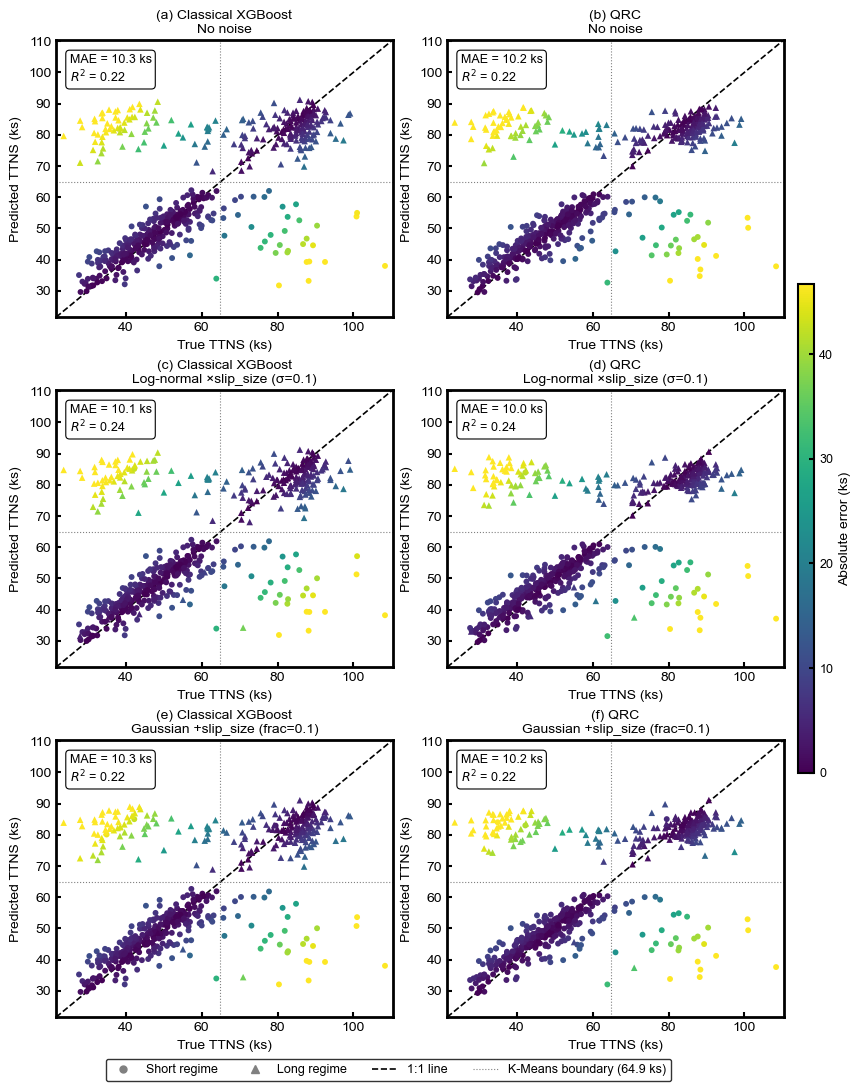

In [32]:
# ── Publication figure: Classical & QRC across noise conditions ───────────────
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np
from matplotlib.lines import Line2D
from sklearn.metrics import mean_absolute_error, r2_score

mpl.rcParams.update({
    'font.family':       'Arial',
    'font.size':         11,
    'axes.linewidth':    2,
    'axes.edgecolor':    'black',
    'axes.facecolor':    'white',
    'figure.facecolor':  'white',
    'axes.grid':         False,
    'xtick.major.width': 1.5,
    'ytick.major.width': 1.5,
    'xtick.direction':   'in',
    'ytick.direction':   'in',
    'xtick.labelsize':   10,
    'ytick.labelsize':   10,
})

y_true = np.array(y_test_np)
km_boundary = centers.mean()

VARIANT_LABELS = ["Clean", "Structured", "Unstructured"]
VARIANT_SUBTITLES = {
    "Clean":        "No noise",
    "Structured":   f"Log-normal ×slip_size (σ={SLIP_STRUCT_LEVEL})",
    "Unstructured": f"Gaussian +slip_size (frac={SLIP_UNSTRUCT_FRAC})",
}

# Collect all predictions for shared axis limits and colorbar
all_preds = []
for vn in VARIANT_LABELS:
    all_preds.append(CLASSICAL_RESULTS[vn]["preds"])
    if vn in NOISE_RESULTS:
        all_preds.append(NOISE_RESULTS[vn]["ensemble_pred"])
all_vals = np.concatenate([y_true] + all_preds)
ax_min = max(0, np.min(all_vals) - 2000)
ax_max = np.max(all_vals) + 2000
diag   = [ax_min, ax_max]

all_errors = np.concatenate([np.abs(p - y_true) for p in all_preds])
vmin, vmax = 0, np.percentile(all_errors, 95)
cmap = plt.cm.viridis
norm = mpl.colors.Normalize(vmin=vmin, vmax=vmax)

short_idx = masks_clean["clf_test_labels"] == 0
long_idx  = masks_clean["clf_test_labels"] == 1

def _format_axes_ks(ax):
    ax.xaxis.set_major_formatter(mpl.ticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}'))
    ax.yaxis.set_major_formatter(mpl.ticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}'))

def scatter_panel(ax, y_true, y_pred, errors, title, short_idx, long_idx, placeholder=False):
    ax.set_xlim(ax_min, ax_max); ax.set_ylim(ax_min, ax_max)
    ax.plot(diag, diag, color='black', linewidth=1.2, linestyle='--', zorder=1)
    ax.axvline(km_boundary, color='grey', linestyle=':', linewidth=0.8, zorder=1)
    ax.axhline(km_boundary, color='grey', linestyle=':', linewidth=0.8, zorder=1)
    if placeholder:
        ax.text(0.5, 0.5, 'Pending', transform=ax.transAxes,
                ha='center', va='center', fontsize=11, color='gray')
    else:
        ax.scatter(y_true[short_idx], y_pred[short_idx],
                   c=errors[short_idx], cmap=cmap, norm=norm,
                   s=18, marker='o', edgecolors='none', zorder=2)
        ax.scatter(y_true[long_idx], y_pred[long_idx],
                   c=errors[long_idx], cmap=cmap, norm=norm,
                   s=22, marker='^', edgecolors='none', zorder=2)
        mae = mean_absolute_error(y_true, y_pred)
        r2  = r2_score(y_true, y_pred)
        ax.text(0.04, 0.95, f'MAE = {mae/1000:.1f} ks\n$R^2$ = {r2:.2f}',
                transform=ax.transAxes, ha='left', va='top', fontsize=9,
                bbox=dict(boxstyle='round,pad=0.3', facecolor='white',
                          edgecolor='black', linewidth=0.8))
    ax.set_title(title, fontsize=10, pad=5)
    ax.set_xlabel('True TTNS (ks)', fontsize=10)
    ax.set_ylabel('Predicted TTNS (ks)', fontsize=10)
    _format_axes_ks(ax)

panel_labels = iter('abcdefghij')

# 3 rows (noise variants) × 2 cols (Classical | QRC)
fig, axes = plt.subplots(3, 2, figsize=(8.5, 10.5), constrained_layout=True)

for row, vn in enumerate(VARIANT_LABELS):
    subtitle = VARIANT_SUBTITLES[vn]

    # Classical
    cl_preds  = CLASSICAL_RESULTS[vn]["preds"]
    cl_errors = np.abs(cl_preds - y_true)
    scatter_panel(axes[row, 0], y_true, cl_preds, cl_errors,
                  f'({next(panel_labels)}) Classical XGBoost\n{subtitle}',
                  short_idx, long_idx)

    # QRC
    if vn in NOISE_RESULTS:
        qrc_preds  = NOISE_RESULTS[vn]["ensemble_pred"]
        qrc_errors = np.abs(qrc_preds - y_true)
        scatter_panel(axes[row, 1], y_true, qrc_preds, qrc_errors,
                      f'({next(panel_labels)}) QRC\n{subtitle}',
                      short_idx, long_idx)
    else:
        scatter_panel(axes[row, 1], y_true, None, None,
                      f'({next(panel_labels)}) QRC\n{subtitle}',
                      short_idx, long_idx, placeholder=True)

# Shared colorbar
sm = mpl.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = fig.colorbar(sm, ax=axes, shrink=0.5, pad=0.02, aspect=30)
cbar.set_label('Absolute error (ks)', fontsize=10)
cbar.ax.yaxis.set_major_formatter(mpl.ticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}'))
cbar.ax.tick_params(labelsize=9)
cbar.outline.set_linewidth(1.5)

legend_elements = [
    Line2D([0],[0], marker='o', color='gray', linestyle='None', markersize=5, label='Short regime'),
    Line2D([0],[0], marker='^', color='gray', linestyle='None', markersize=6, label='Long regime'),
    Line2D([0],[0], color='black', linestyle='--', linewidth=1.2, label='1:1 line'),
    Line2D([0],[0], color='grey',  linestyle=':', linewidth=0.8,
           label=f'K-Means boundary ({km_boundary/1000:.1f} ks)'),
]
fig.legend(handles=legend_elements, loc='lower center', ncol=4, fontsize=9,
           frameon=True, edgecolor='black', bbox_to_anchor=(0.45, -0.03))

plt.show()


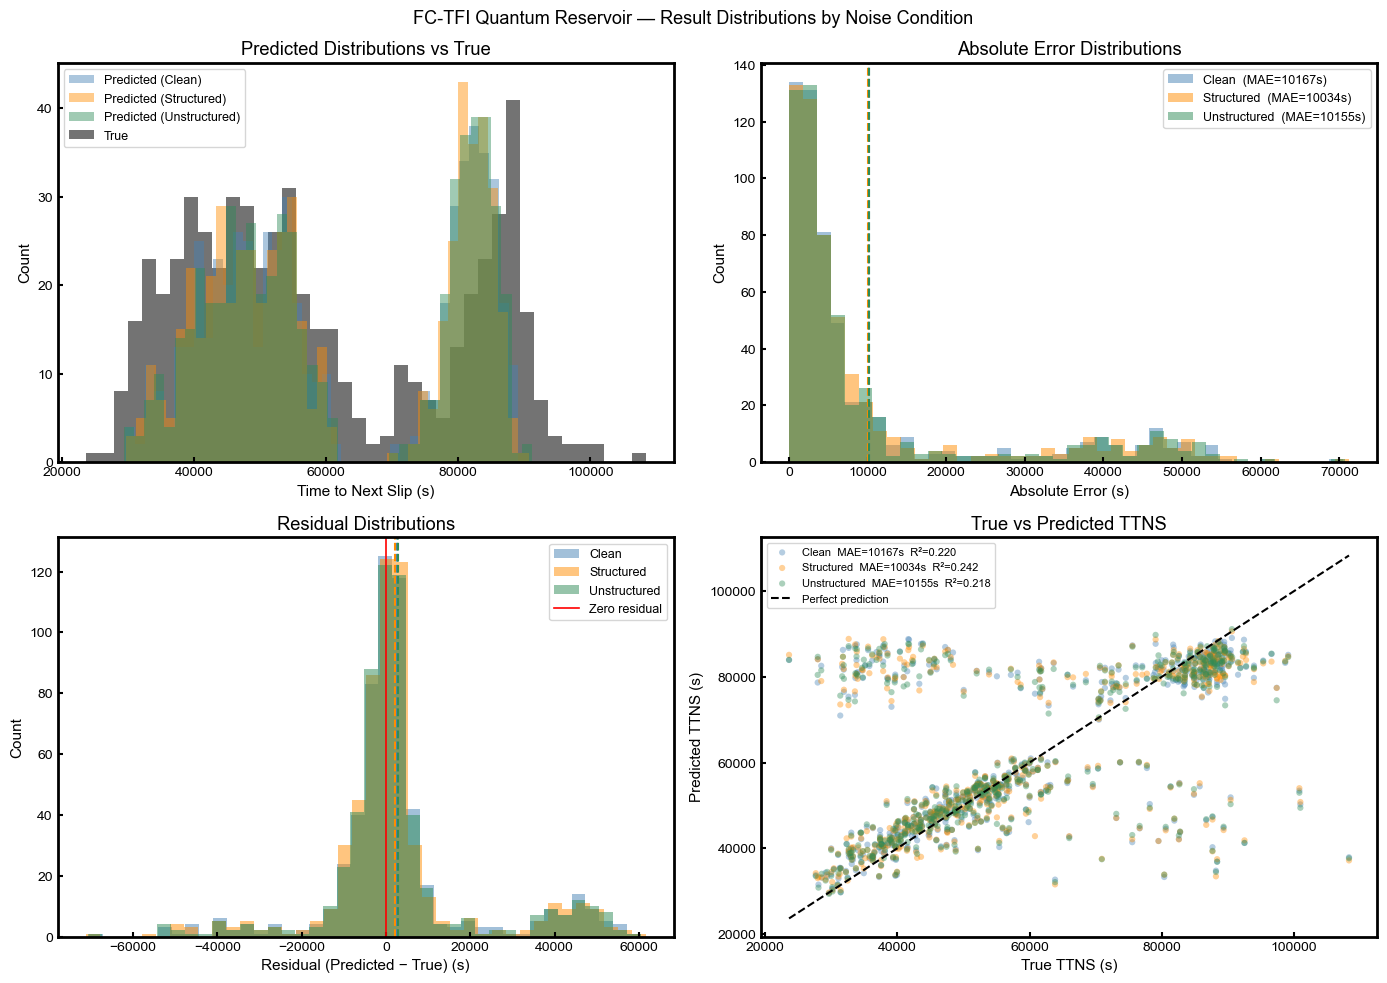


=== QRC Summary ===
  Clean         MAE=10167.30s  Median AE=3923.87s  R2=0.2196
  Structured    MAE=10034.03s  Median AE=3896.83s  R2=0.2417
  Unstructured  MAE=10155.29s  Median AE=3893.51s  R2=0.2180


In [33]:
# ── Distribution plots — Clean / Structured / Unstructured (QRC) ─────────────
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import mean_absolute_error, r2_score

COLORS = {"Clean": "steelblue", "Structured": "darkorange", "Unstructured": "seagreen"}

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("FC-TFI Quantum Reservoir — Result Distributions by Noise Condition", fontsize=13)

for vn, color in COLORS.items():
    if vn not in NOISE_RESULTS:
        continue
    qrc_preds = NOISE_RESULTS[vn]["ensemble_pred"]
    abs_errs  = np.abs(qrc_preds - y_test_np)
    residuals = qrc_preds - y_test_np

    lbl = vn

    # Panel 1: True vs Predicted distributions
    axes[0, 0].hist(qrc_preds, bins=40, alpha=0.45, color=color, label=f'Predicted ({lbl})')

axes[0, 0].hist(y_test_np, bins=40, alpha=0.55, color='black', label='True', zorder=0)
axes[0, 0].set_xlabel("Time to Next Slip (s)"); axes[0, 0].set_ylabel("Count")
axes[0, 0].set_title("Predicted Distributions vs True"); axes[0, 0].legend(fontsize=9)

# Panel 2: Absolute error distributions
for vn, color in COLORS.items():
    if vn not in NOISE_RESULTS:
        continue
    qrc_preds = NOISE_RESULTS[vn]["ensemble_pred"]
    abs_errs  = np.abs(qrc_preds - y_test_np)
    mae_v     = mean_absolute_error(y_test_np, qrc_preds)
    axes[0, 1].hist(abs_errs, bins=40, alpha=0.5, color=color,
                    label=f'{vn}  (MAE={mae_v:.0f}s)')
    axes[0, 1].axvline(abs_errs.mean(), color=color, linestyle='--', linewidth=1.5)

axes[0, 1].set_xlabel("Absolute Error (s)"); axes[0, 1].set_ylabel("Count")
axes[0, 1].set_title("Absolute Error Distributions"); axes[0, 1].legend(fontsize=9)

# Panel 3: Residuals
for vn, color in COLORS.items():
    if vn not in NOISE_RESULTS:
        continue
    qrc_preds = NOISE_RESULTS[vn]["ensemble_pred"]
    residuals = qrc_preds - y_test_np
    axes[1, 0].hist(residuals, bins=40, alpha=0.5, color=color, label=vn)
    axes[1, 0].axvline(residuals.mean(), color=color, linestyle='--', linewidth=1.5)

axes[1, 0].axvline(0, color='red', linestyle='-', linewidth=1.2, label='Zero residual')
axes[1, 0].set_xlabel("Residual (Predicted − True) (s)"); axes[1, 0].set_ylabel("Count")
axes[1, 0].set_title("Residual Distributions"); axes[1, 0].legend(fontsize=9)

# Panel 4: Scatter (clean only as reference; add others as contour or separate)
for vn, color in COLORS.items():
    if vn not in NOISE_RESULTS:
        continue
    qrc_preds = NOISE_RESULTS[vn]["ensemble_pred"]
    abs_errs  = np.abs(qrc_preds - y_test_np)
    mae_v = mean_absolute_error(y_test_np, qrc_preds)
    r2_v  = r2_score(y_test_np, qrc_preds)
    axes[1, 1].scatter(y_test_np, qrc_preds, c=color, s=20, alpha=0.4,
                       edgecolors='none', label=f'{vn}  MAE={mae_v:.0f}s  R²={r2_v:.3f}')

ref = np.array([y_test_np.min(), y_test_np.max()])
axes[1, 1].plot(ref, ref, 'k--', linewidth=1.5, label='Perfect prediction')
axes[1, 1].set_xlabel("True TTNS (s)"); axes[1, 1].set_ylabel("Predicted TTNS (s)")
axes[1, 1].set_title("True vs Predicted TTNS"); axes[1, 1].legend(fontsize=8)

plt.tight_layout()
plt.show()

print("\n=== QRC Summary ===")
for vn in COLORS:
    if vn not in NOISE_RESULTS:
        continue
    ep = NOISE_RESULTS[vn]["ensemble_pred"]
    ae = np.abs(ep - y_test_np)
    print(f"  {vn:12s}  MAE={mean_absolute_error(y_test_np,ep):.2f}s  "
          f"Median AE={np.median(ae):.2f}s  R2={r2_score(y_test_np,ep):.4f}")


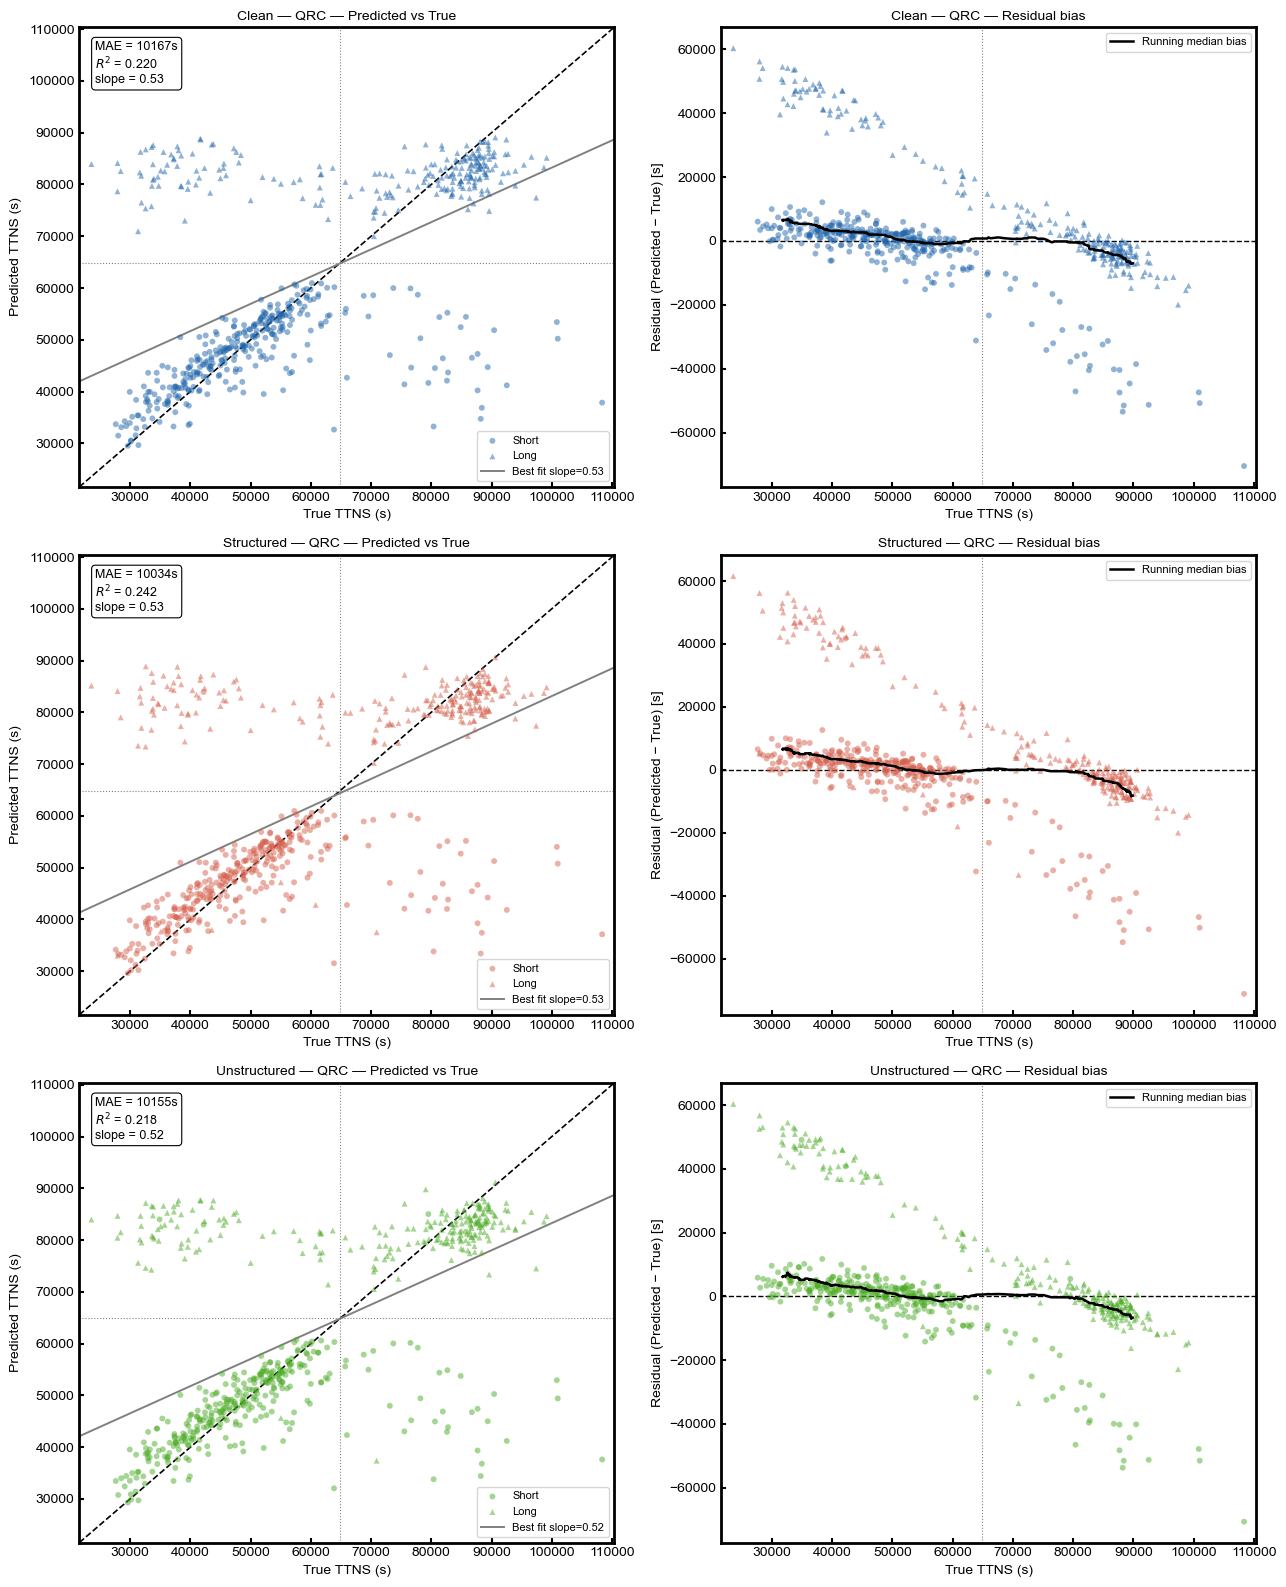

In [34]:
# ── Prediction diagnostic — scatter + residual bias (all noise conditions) ────
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np
from sklearn.metrics import mean_absolute_error, r2_score
from scipy.stats import linregress

COLORS = {"Clean": "#2166ac", "Structured": "#d6604d", "Unstructured": "#4dac26"}
SHORT_M = masks_clean["clf_test_labels"] == 0
LONG_M  = masks_clean["clf_test_labels"] == 1
DOT_S   = 18
ALPHA   = 0.5
km_boundary = centers.mean()

fig, axes = plt.subplots(3, 2, figsize=(13, 16))

for row, (vn, color) in enumerate(COLORS.items()):
    # Prefer QRC if available, fall back to classical
    if vn in NOISE_RESULTS:
        preds = NOISE_RESULTS[vn]["ensemble_pred"]
        model_label = f"{vn} — QRC"
    else:
        preds = CLASSICAL_RESULTS[vn]["preds"]
        model_label = f"{vn} — Classical"

    signed = preds - y_test_np
    lim = [max(0, min(y_test_np.min(), preds.min()) - 2000),
               max(y_test_np.max(), preds.max()) + 2000]

    ax_sc, ax_res = axes[row, 0], axes[row, 1]

    # Scatter
    ax_sc.scatter(y_test_np[SHORT_M], preds[SHORT_M], color=color,
                  s=DOT_S, alpha=ALPHA, edgecolors='none', label='Short', zorder=3)
    ax_sc.scatter(y_test_np[LONG_M], preds[LONG_M], color=color,
                  s=DOT_S, marker='^', alpha=ALPHA, edgecolors='none', label='Long', zorder=3)
    ax_sc.plot(lim, lim, 'k--', lw=1.2, zorder=2)
    ax_sc.axvline(km_boundary, color='grey', lw=0.8, ls=':', zorder=1)
    ax_sc.axhline(km_boundary, color='grey', lw=0.8, ls=':', zorder=1)

    slope, intercept, *_ = linregress(y_test_np, preds)
    x_fit = np.linspace(lim[0], lim[1], 300)
    ax_sc.plot(x_fit, slope*x_fit+intercept, color='grey', lw=1.4,
               label=f'Best fit slope={slope:.2f}')

    mae = mean_absolute_error(y_test_np, preds)
    r2  = r2_score(y_test_np, preds)
    ax_sc.text(0.03, 0.97, f'MAE = {mae:.0f}s\n$R^2$ = {r2:.3f}\nslope = {slope:.2f}',
               transform=ax_sc.transAxes, ha='left', va='top', fontsize=9,
               bbox=dict(boxstyle='round,pad=0.3', fc='white', ec='black', lw=0.8))
    ax_sc.set_xlim(lim); ax_sc.set_ylim(lim)
    ax_sc.set_xlabel('True TTNS (s)', fontsize=10)
    ax_sc.set_ylabel('Predicted TTNS (s)', fontsize=10)
    ax_sc.set_title(f'{model_label} — Predicted vs True', fontsize=10)
    ax_sc.legend(fontsize=8, loc='lower right')

    # Residuals
    ax_res.axhline(0, color='black', lw=1.0, ls='--', zorder=2)
    ax_res.axvline(km_boundary, color='grey', lw=0.8, ls=':', zorder=1)
    ax_res.scatter(y_test_np[SHORT_M], signed[SHORT_M], color=color,
                   s=DOT_S, alpha=ALPHA, edgecolors='none', zorder=3)
    ax_res.scatter(y_test_np[LONG_M], signed[LONG_M], color=color,
                   s=DOT_S, marker='^', alpha=ALPHA, edgecolors='none', zorder=3)

    order  = np.argsort(y_test_np)
    y_sort = y_test_np[order]; s_sort = signed[order]
    win    = max(1, len(y_sort)//12)
    med_x  = [np.median(y_sort[max(0,i-win):i+win]) for i in range(len(y_sort))]
    med_y  = [np.median(s_sort[max(0,i-win):i+win]) for i in range(len(s_sort))]
    ax_res.plot(med_x, med_y, color='black', lw=1.8, zorder=5, label='Running median bias')

    ax_res.set_xlabel('True TTNS (s)', fontsize=10)
    ax_res.set_ylabel('Residual (Predicted − True) [s]', fontsize=10)
    ax_res.set_title(f'{model_label} — Residual bias', fontsize=10)
    ax_res.legend(fontsize=8)
    ax_res.set_xlim(lim[0], lim[1])

plt.tight_layout()
plt.show()


  Classical XGBoost
  ──────────────────────────────────────────────────────
  High-confidence subset (≥80%, n=281)
    MAE  : 5340 s
    R²   : 0.6925
  Full pipeline (n=565)
    MAE  : 10255 s
    R²   : 0.2214

  Noiseless QRC
  ──────────────────────────────────────────────────────
  High-confidence subset (≥80%, n=281)
    MAE  : 5240 s
    R²   : 0.6940
  Full pipeline (n=565)
    MAE  : 10167 s
    R²   : 0.2196



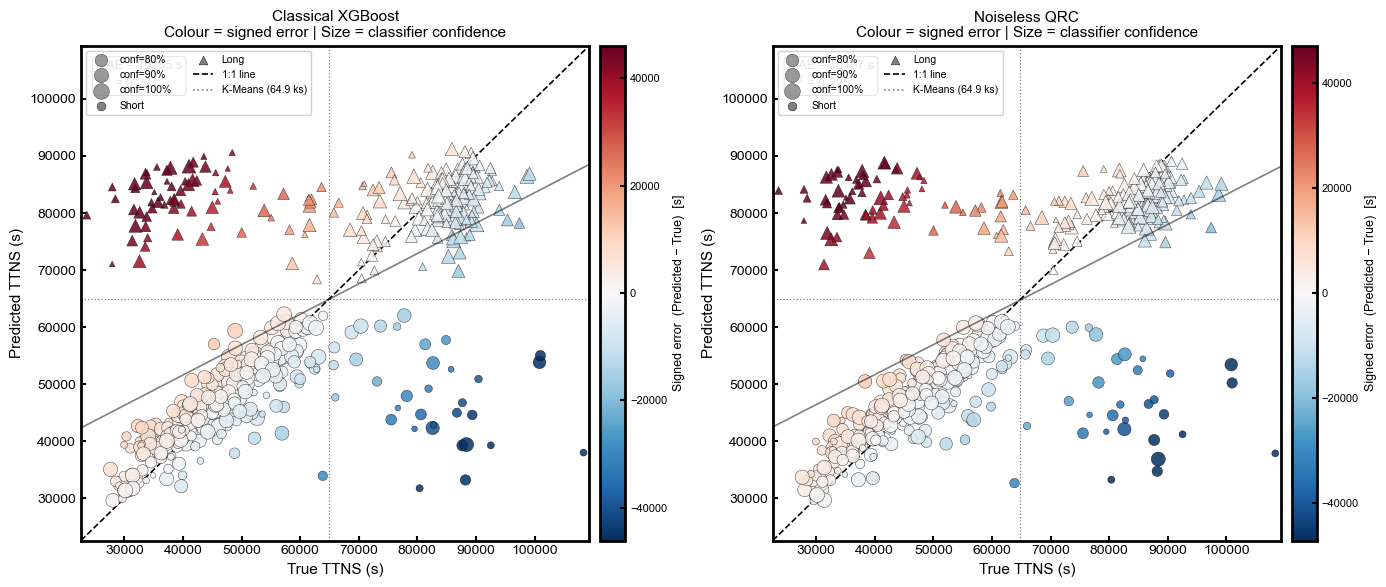

In [35]:
# ── Additional Scatter plot — colour = signed error, size = classifier confidence ─────────────────────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np
from sklearn.metrics import mean_absolute_error, r2_score
from scipy.stats import linregress

# ── Print results table ───────────────────────────────────────────────────────
try:
    _qrc_preds_sc = np.array(ensemble_pred)
    _qrc_available = True
except NameError:
    _qrc_available = False

def _print_results(label, preds, y_np, hc_idx):
    print(f"  {label}")
    print(f"  {'─'*54}")
    print(f"  High-confidence subset (≥80%, n={len(hc_idx)})")
    print(f"    MAE  : {mean_absolute_error(y_np[hc_idx], preds[hc_idx]):.0f} s")
    print(f"    R²   : {r2_score(y_np[hc_idx], preds[hc_idx]):.4f}")
    print(f"  Full pipeline (n={len(y_np)})")
    print(f"    MAE  : {mean_absolute_error(y_np, preds):.0f} s")
    print(f"    R²   : {r2_score(y_np, preds):.4f}")
    print()

print("=" * 60)
_print_results("Classical XGBoost", final_predictions, y_test_np, high_conf_idx)
if _qrc_available:
    _print_results("Noiseless QRC", _qrc_preds_sc, y_test_np, high_conf_idx)
print("=" * 60)

# ── Plotting helper ───────────────────────────────────────────────────────────
def _draw_scatter(ax, y_np, preds, conf, regime_labels, title):
    """
    y_np          : true values
    preds         : predicted values
    conf          : per-sample classifier confidence (0-1)
    regime_labels : 0 = Short, 1 = Long
    """
    signed_err  = preds - y_np                         # + = over-pred, − = under-pred
    max_abs     = np.percentile(np.abs(signed_err), 95)

    # Map confidence → marker size (range 15–120)
    sizes = 15 + (conf - conf.min()) / (conf.max() - conf.min() + 1e-9) * 105

    short_m = regime_labels == 0
    long_m  = regime_labels == 1

    cmap = plt.cm.RdBu_r
    norm = mpl.colors.Normalize(vmin=-max_abs, vmax=max_abs)

    # Short regime — circles
    sc1 = ax.scatter(y_np[short_m], preds[short_m],
                     c=signed_err[short_m], cmap=cmap, norm=norm,
                     s=sizes[short_m], marker='o',
                     edgecolors='black', linewidths=0.3,
                     alpha=0.85, zorder=3, label='Short regime')
    # Long regime — triangles
    ax.scatter(y_np[long_m], preds[long_m],
               c=signed_err[long_m], cmap=cmap, norm=norm,
               s=sizes[long_m], marker='^',
               edgecolors='black', linewidths=0.3,
               alpha=0.85, zorder=3, label='Long regime')

    # 1:1 line
    lim = [max(0, min(y_np.min(), preds.min()) - 1000),
               max(y_np.max(), preds.max()) + 1000]
    ax.plot(lim, lim, 'k--', lw=1.2, zorder=2, label='1:1 line')

    # K-Means boundary
    km_boundary = centers.mean()
    ax.axvline(km_boundary, color='grey', linestyle=':', lw=0.9, zorder=1)
    ax.axhline(km_boundary, color='grey', linestyle=':', lw=0.9, zorder=1)

    # Line of best fit
    slope, intercept, *_ = linregress(y_np, preds)
    x_fit = np.linspace(lim[0], lim[1], 300)
    ax.plot(x_fit, slope * x_fit + intercept, 'k-', lw=1.2, alpha=0.5,
            label=f'Best fit (slope={slope:.2f})', zorder=4)

    ax.set_xlim(lim); ax.set_ylim(lim)
    ax.set_xlabel('True TTNS (s)', fontsize=11)
    ax.set_ylabel('Predicted TTNS (s)', fontsize=11)
    ax.set_title(title, fontsize=11)

    mae  = mean_absolute_error(y_np, preds)
    r2   = r2_score(y_np, preds)
    ax.text(0.03, 0.97,
            f'MAE = {mae:.0f} s\n$R^2$ = {r2:.3f}',
            transform=ax.transAxes, ha='left', va='top', fontsize=9,
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white',
                      edgecolor='black', lw=0.8))

    # Colourbar
    sm = mpl.cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    cb = plt.colorbar(sm, ax=ax, pad=0.02, fraction=0.046)
    cb.set_label('Signed error  (Predicted − True)  [s]', fontsize=9)
    cb.ax.tick_params(labelsize=8)

    # Size legend
    conf_levels = [0.80, 0.90, 1.00]
    size_levels = [15 + (c - conf.min()) / (conf.max() - conf.min() + 1e-9) * 105
                   for c in conf_levels]
    handles_size = [
        plt.scatter([], [], s=sz, color='grey', edgecolors='black',
                    lw=0.3, alpha=0.8, label=f'conf={cl:.0%}')
        for sz, cl in zip(size_levels, conf_levels)
    ]
    handles_shape = [
        plt.scatter([], [], s=40, marker='o', color='grey',
                    edgecolors='black', lw=0.3, label='Short'),
        plt.scatter([], [], s=40, marker='^', color='grey',
                    edgecolors='black', lw=0.3, label='Long'),
        plt.Line2D([0],[0], color='k', lw=1.2, linestyle='--', label='1:1 line'),
        plt.Line2D([0],[0], color='grey', lw=1.2, linestyle=':', label=f'K-Means ({km_boundary/1000:.1f} ks)'),
    ]
    ax.legend(handles=handles_size + handles_shape,
              fontsize=7.5, loc='upper left',
              ncol=2, framealpha=0.9)


n_panels = 2 if _qrc_available else 1
fig, axes = plt.subplots(1, n_panels, figsize=(7 * n_panels, 6), squeeze=False)

conf_all = max_conf   # from Cell 13

_draw_scatter(axes[0, 0], y_test_np, final_predictions,
              conf_all, clf_test_labels,
              'Classical XGBoost\nColour = signed error | Size = classifier confidence')

if _qrc_available:
    _draw_scatter(axes[0, 1], y_test_np, _qrc_preds_sc,
                  conf_all, clf_test_labels,
                  'Noiseless QRC\nColour = signed error | Size = classifier confidence')

plt.tight_layout()
plt.show()


Expected feature columns : 126  (6 base × 21 lags)
X_train_raw columns      : 126


c:\Users\kaitl\anaconda3\envs\icequake-qrc\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=7.
  warnings.warn(


Running SHAP KernelExplainer (this may take a few minutes)...


 39%|███▉      | 78/200 [00:02<00:04, 27.38it/s]c:\Users\kaitl\anaconda3\envs\icequake-qrc\Lib\site-packages\sklearn\linear_model\_least_angle.py:723: ConvergenceWarning: Regressors in active set degenerate. Dropping a regressor, after 9 iterations, i.e. alpha=1.702e+02, with an active set of 9 regressors, and the smallest cholesky pivot element being 2.220e-16. Reduce max_iter or increase eps parameters.
  warnings.warn(
 72%|███████▏  | 144/200 [00:05<00:01, 28.49it/s]c:\Users\kaitl\anaconda3\envs\icequake-qrc\Lib\site-packages\shap\explainers\_kernel.py:708: UserWarning: Linear regression equation is singular, a least squares solutions is used instead.
To avoid this situation and get a regular matrix do one of the following:
1) turn up the number of samples,
2) turn up the L1 regularization with num_features(N) where N is less than the number of samples,
3) group features together to reduce the number of inputs that need to be explained.
  warnings.warn(
100%|██████████| 200/200 [00

shap_values shape: (200, 126)


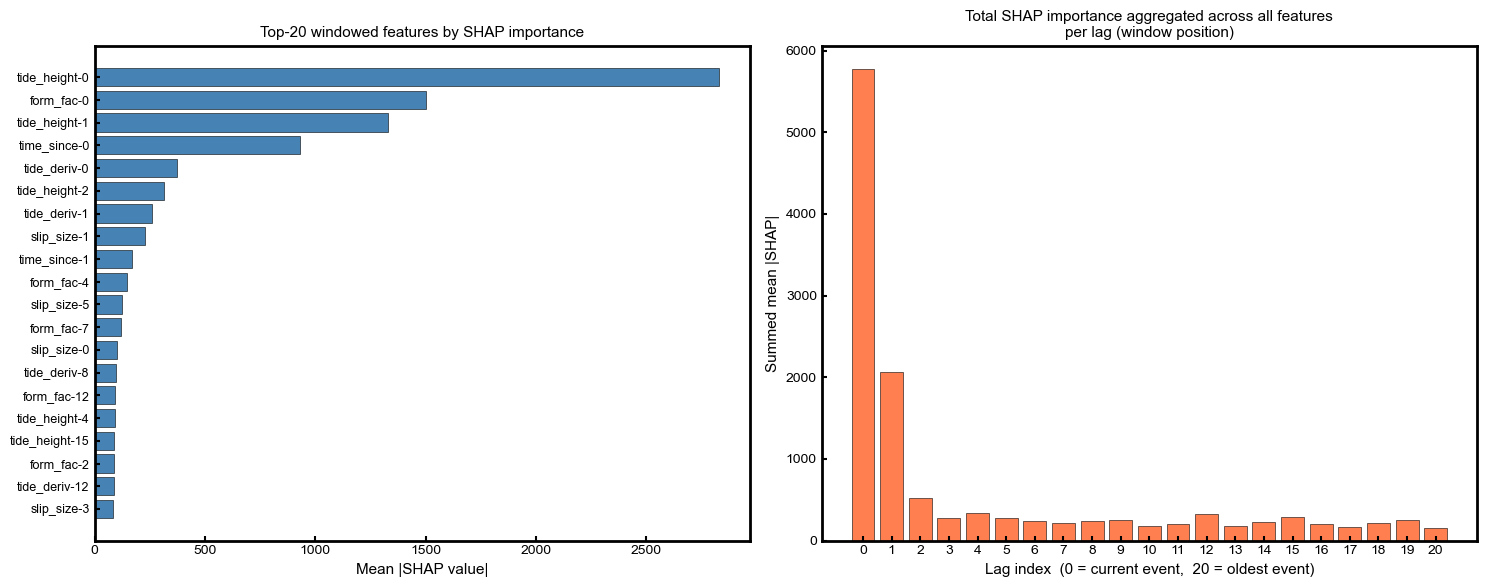

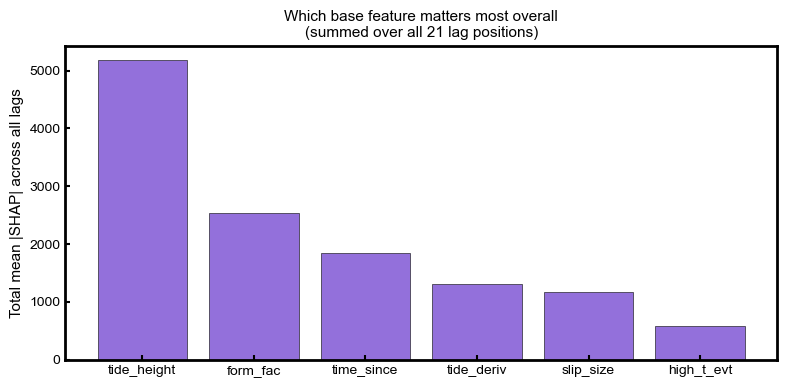

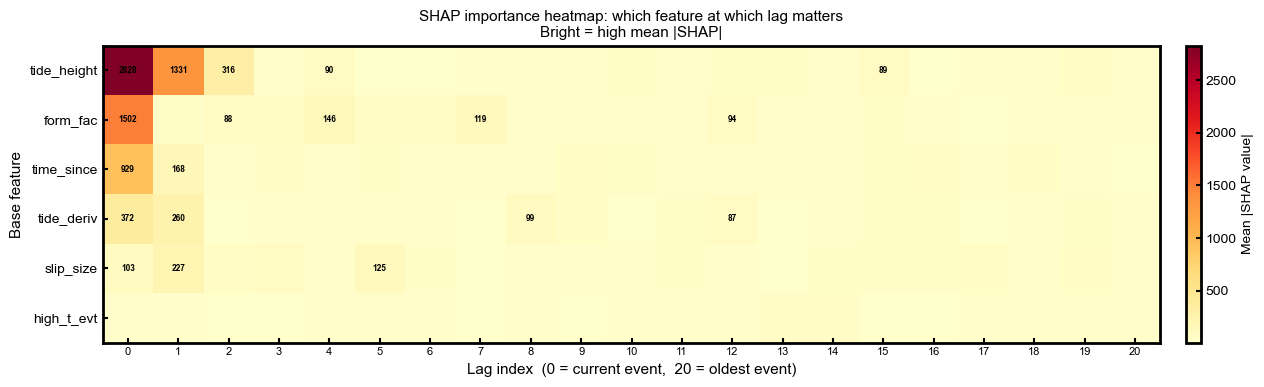

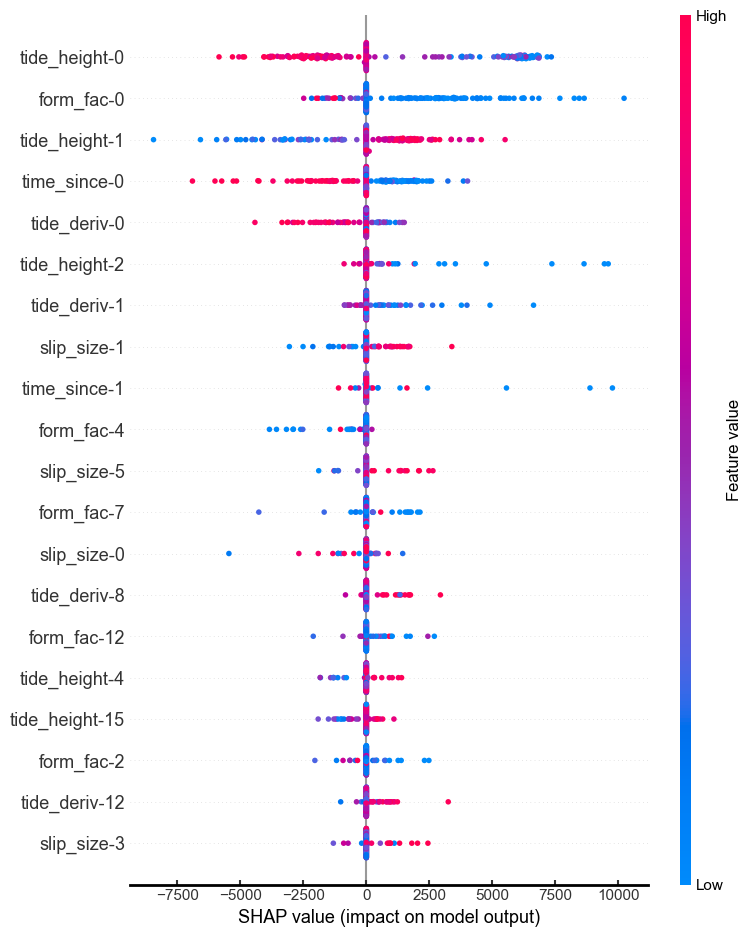

In [36]:
# SHAP feature importance 
import shap
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl

# ── 1. Build full windowed column names to match X_train_raw ─────────────────
#    preprocess_data_window returns feature_cols = the BASE names (6 of them).
#    The actual DataFrame columns are {base}-0 … {base}-{n_previous_events}.
n_lags      = n_previous_events + 1   # 21 columns per base feature (lag 0..20)
base_feats  = list(feature_cols)       # ['tide_deriv','form_fac','time_since','slip_size','high_t_evt','tide_height']

# Reconstruct column order to match pd.concat([windows[0], windows[1], ...])
# windows[0] = current event (lag 0), windows[1] = lag 1, ...
# concat axis=1 → columns are: all 6 base-0, then all 6 base-1, ...
full_col_names = []
for lag in range(n_lags):
    for base in base_feats:
        full_col_names.append(f"{base}-{lag}")

n_features_expected = len(full_col_names)
n_features_raw      = X_train_raw.shape[1]

print(f"Expected feature columns : {n_features_expected}  (6 base × {n_lags} lags)")
print(f"X_train_raw columns      : {n_features_raw}")

if n_features_expected != n_features_raw:
    print(f"WARNING: mismatch — trimming/padding to match X_train_raw.")
    if n_features_expected > n_features_raw:
        full_col_names = full_col_names[:n_features_raw]
    else:
        full_col_names += [f"unknown-{i}" for i in range(n_features_expected, n_features_raw)]

feat_names = full_col_names
n_features = n_features_raw

# ── 2. Background + explain set ───────────────────────────────────────────────
background  = shap.kmeans(X_train_raw, 50)
rng_shap    = np.random.default_rng(0)
explain_idx = rng_shap.choice(len(X_test_raw),
                               size=min(200, len(X_test_raw)),
                               replace=False)

def routing_predict(X_arr):
    labels = slip_classifier.predict(X_arr)
    out    = np.empty(len(X_arr))
    s_idx  = np.where(labels == 0)[0]
    l_idx  = np.where(labels == 1)[0]
    if len(s_idx): out[s_idx] = XGBoost_short.predict(X_arr[s_idx])
    if len(l_idx): out[l_idx] = XGBoost_long.predict(X_arr[l_idx])
    return out

print("Running SHAP KernelExplainer (this may take a few minutes)...")
explainer   = shap.KernelExplainer(routing_predict, background)
shap_values = explainer.shap_values(X_test_raw[explain_idx], nsamples=100)
print(f"shap_values shape: {shap_values.shape}")

mean_abs_shap = np.abs(shap_values).mean(axis=0)
assert len(mean_abs_shap) == len(feat_names), (
    f"Shape mismatch: {len(mean_abs_shap)} SHAP values vs {len(feat_names)} names"
)

# ── 3. Parse lag and base feature from each column name ──────────────────────
def parse_col(col):
    """Split 'form_fac-3' → ('form_fac', 3). Returns (col, None) if no match."""
    m = re.match(r'^(.+)-([0-9]+)$', col)
    if m:
        return m.group(1), int(m.group(2))
    return col, None

shap_df = pd.DataFrame({
    'col':           feat_names,
    'mean_abs_shap': mean_abs_shap,
})
parsed           = shap_df['col'].apply(parse_col)
shap_df['base']  = parsed.apply(lambda x: x[0])
shap_df['lag']   = parsed.apply(lambda x: x[1])

# ── 4. Top-20 individual column importance ────────────────────────────────────
top20        = shap_df.nlargest(20, 'mean_abs_shap')
top_feat_idx = top20.index.tolist()

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

axes[0].barh(top20['col'].values[::-1],
             top20['mean_abs_shap'].values[::-1],
             color='steelblue', edgecolor='black', linewidth=0.4)
axes[0].set_xlabel('Mean |SHAP value|', fontsize=11)
axes[0].set_title('Top-20 windowed features by SHAP importance', fontsize=11)
axes[0].tick_params(axis='y', labelsize=9)

# ── 5. Per-lag aggregated importance (correctly parsed) ───────────────────────
lag_shap = (
    shap_df.dropna(subset=['lag'])
           .groupby('lag')['mean_abs_shap']
           .sum()
           .reindex(range(n_lags), fill_value=0)
)
axes[1].bar(lag_shap.index, lag_shap.values,
            color='coral', edgecolor='black', linewidth=0.4)
axes[1].set_xlabel('Lag index  (0 = current event,  20 = oldest event)', fontsize=11)
axes[1].set_ylabel('Summed mean |SHAP|', fontsize=11)
axes[1].set_title(f'Total SHAP importance aggregated across all features\n'
                  f'per lag (window position)', fontsize=11)
axes[1].set_xticks(range(n_lags))
plt.tight_layout()
plt.show()

# ── 6. Per-base-feature importance across all lags ────────────────────────────
base_shap = (
    shap_df.groupby('base')['mean_abs_shap']
           .sum()
           .sort_values(ascending=False)
)
fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(base_shap.index, base_shap.values,
       color='mediumpurple', edgecolor='black', linewidth=0.4)
ax.set_ylabel('Total mean |SHAP| across all lags', fontsize=11)
ax.set_title('Which base feature matters most overall\n'
             '(summed over all 21 lag positions)', fontsize=11)
ax.tick_params(axis='x', labelsize=10)
plt.tight_layout()
plt.show()

# ── 7. Heatmap: base_feature × lag ────────────────────────────────────────────
#    This is the most informative view: shows WHICH feature at WHICH lag matters.
#    A bright cell at (form_fac, lag=0) means current-event form factor dominates.
#    A bright cell at (form_fac, lag=11) means 11-events-ago form factor matters.
pivot = shap_df.dropna(subset=['lag']).pivot_table(
    index='base', columns='lag', values='mean_abs_shap', aggfunc='sum'
)
# Reorder rows by total importance
pivot = pivot.loc[base_shap.index]
pivot = pivot.reindex(columns=range(n_lags), fill_value=0)

fig, ax = plt.subplots(figsize=(14, 4))
im = ax.imshow(pivot.values, aspect='auto', cmap='YlOrRd',
               interpolation='nearest')
ax.set_xticks(range(n_lags))
ax.set_xticklabels(range(n_lags), fontsize=8)
ax.set_yticks(range(len(pivot.index)))
ax.set_yticklabels(pivot.index, fontsize=10)
ax.set_xlabel('Lag index  (0 = current event,  20 = oldest event)', fontsize=11)
ax.set_ylabel('Base feature', fontsize=11)
ax.set_title('SHAP importance heatmap: which feature at which lag matters\n'
             'Bright = high mean |SHAP|', fontsize=11)

cbar = plt.colorbar(im, ax=ax, pad=0.02)
cbar.set_label('Mean |SHAP value|', fontsize=10)

# Annotate cells with values for the top entries
threshold = np.percentile(pivot.values, 85)
for i in range(pivot.shape[0]):
    for j in range(pivot.shape[1]):
        val = pivot.values[i, j]
        if val >= threshold:
            ax.text(j, i, f'{val:.0f}', ha='center', va='center',
                    fontsize=6, color='black', fontweight='bold')

plt.tight_layout()
plt.show()

# ── 8. SHAP beeswarm on top-20 features ──────────────────────────────────────
shap.summary_plot(
    shap_values[:, top_feat_idx],
    X_test_raw[explain_idx][:, top_feat_idx],
    feature_names=[feat_names[i] for i in top_feat_idx],
    plot_type='dot',
    max_display=20,
    show=True
)


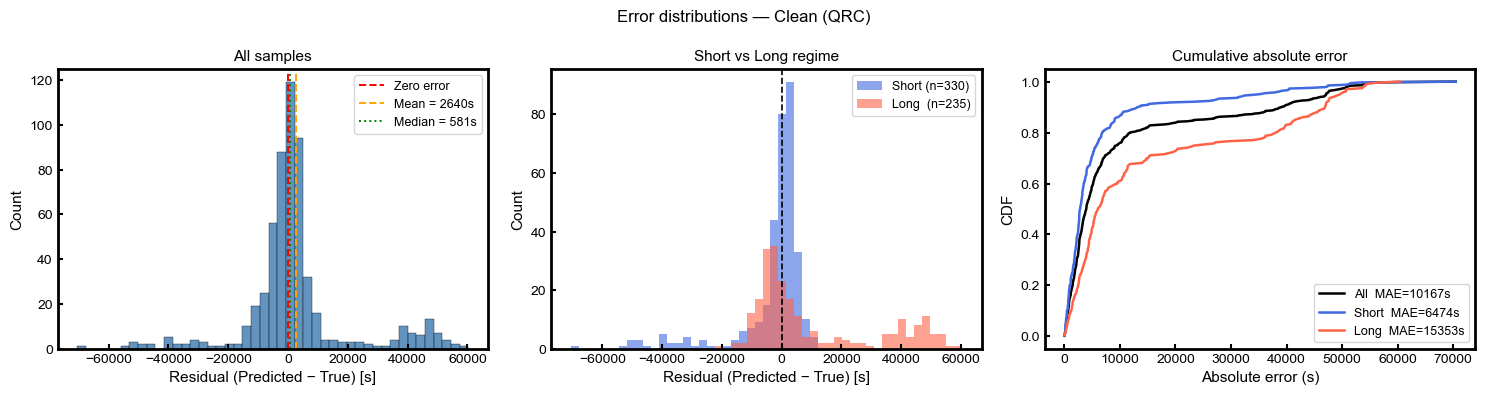

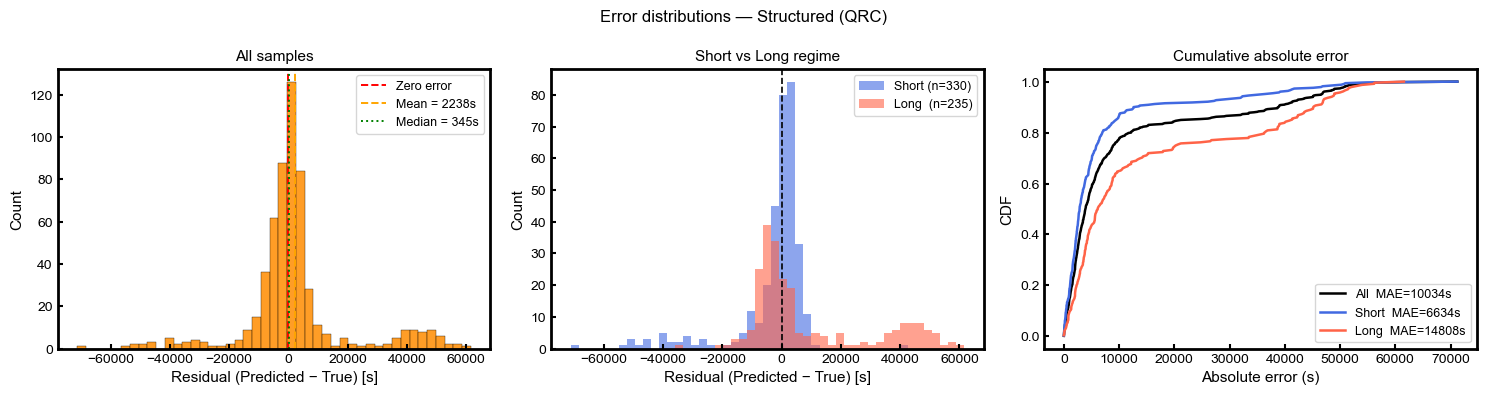

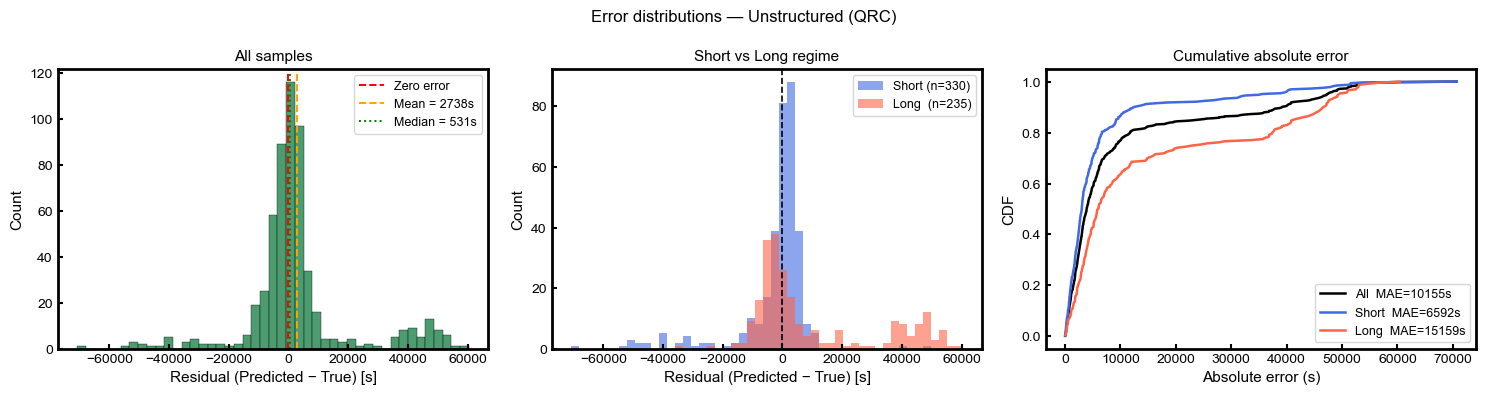

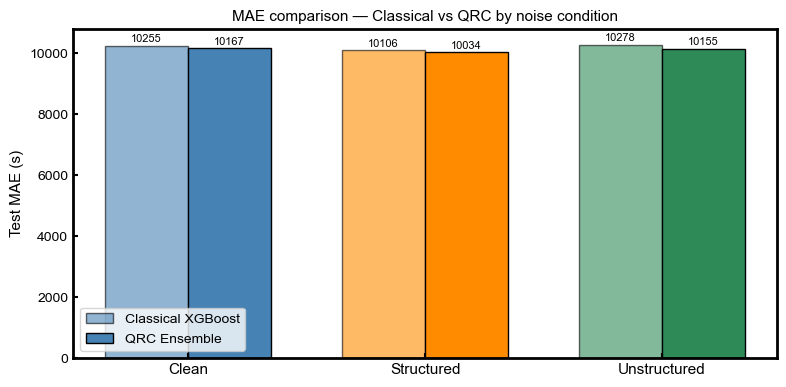

In [37]:
# ── Error distribution plots — Clean / Structured / Unstructured ─────────────
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import mean_absolute_error

COLORS = {"Clean": "steelblue", "Structured": "darkorange", "Unstructured": "seagreen"}
short_clf_idx = np.where(masks_clean["clf_test_labels"] == 0)[0]
long_clf_idx  = np.where(masks_clean["clf_test_labels"] == 1)[0]

# Prefer QRC results; fall back to classical
def _get_preds(vn):
    if vn in NOISE_RESULTS:
        return NOISE_RESULTS[vn]["ensemble_pred"], "QRC"
    return CLASSICAL_RESULTS[vn]["preds"], "Classical"

for vn, color in COLORS.items():
    preds, source = _get_preds(vn)
    errors_all   = preds - y_test_np
    abs_err_all  = np.abs(errors_all)
    errors_short = errors_all[short_clf_idx]
    errors_long  = errors_all[long_clf_idx]

    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    fig.suptitle(f"Error distributions — {vn} ({source})", fontsize=12)

    # Panel 1: signed residuals
    ax = axes[0]
    ax.hist(errors_all, bins=45, color=color, edgecolor='black', linewidth=0.3, alpha=0.85)
    ax.axvline(0,                   color='red',    linestyle='--', lw=1.4, label='Zero error')
    ax.axvline(errors_all.mean(),   color='orange', linestyle='--', lw=1.4,
               label=f'Mean = {errors_all.mean():.0f}s')
    ax.axvline(np.median(errors_all), color='green', linestyle=':', lw=1.4,
               label=f'Median = {np.median(errors_all):.0f}s')
    ax.set_xlabel('Residual (Predicted − True) [s]', fontsize=11)
    ax.set_ylabel('Count'); ax.set_title('All samples', fontsize=11)
    ax.legend(fontsize=9)

    # Panel 2: regime-split residuals
    ax = axes[1]
    bins = np.linspace(errors_all.min(), errors_all.max(), 50)
    ax.hist(errors_short, bins=bins, alpha=0.6, color='royalblue',
            label=f'Short (n={len(errors_short)})')
    ax.hist(errors_long,  bins=bins, alpha=0.6, color='tomato',
            label=f'Long  (n={len(errors_long)})')
    ax.axvline(0, color='black', linestyle='--', lw=1.2)
    ax.set_xlabel('Residual (Predicted − True) [s]', fontsize=11)
    ax.set_ylabel('Count'); ax.set_title('Short vs Long regime', fontsize=11)
    ax.legend(fontsize=9)

    # Panel 3: CDF of absolute errors
    ax = axes[2]
    for lbl, idx, c in [('All', np.arange(len(y_test_np)), 'black'),
                         ('Short', short_clf_idx, 'royalblue'),
                         ('Long',  long_clf_idx,  'tomato')]:
        ae  = np.sort(np.abs(errors_all[idx]))
        cdf = np.arange(1, len(ae)+1) / len(ae)
        ax.plot(ae, cdf, color=c, lw=1.8, label=f'{lbl}  MAE={ae.mean():.0f}s')
    ax.set_xlabel('Absolute error (s)', fontsize=11)
    ax.set_ylabel('CDF'); ax.set_title('Cumulative absolute error', fontsize=11)
    ax.legend(fontsize=9)

    plt.tight_layout()
    plt.show()

# ── Side-by-side summary bar chart ───────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 4))
x      = np.arange(len(COLORS))
width  = 0.35
names  = list(COLORS.keys())
maes_classical = [CLASSICAL_RESULTS[vn]["mae"] for vn in names]
maes_qrc       = [mean_absolute_error(y_test_np, NOISE_RESULTS[vn]["ensemble_pred"])
                  if vn in NOISE_RESULTS else float('nan') for vn in names]

bars1 = ax.bar(x - width/2, maes_classical, width, label='Classical XGBoost',
               color=[COLORS[n] for n in names], alpha=0.6, edgecolor='black')
bars2 = ax.bar(x + width/2, maes_qrc,       width, label='QRC Ensemble',
               color=[COLORS[n] for n in names], alpha=1.0, edgecolor='black')

for bar in bars1 + bars2:
    h = bar.get_height()
    if not np.isnan(h):
        ax.text(bar.get_x() + bar.get_width()/2, h + 50, f'{h:.0f}',
                ha='center', va='bottom', fontsize=8)

ax.set_xticks(x); ax.set_xticklabels(names, fontsize=11)
ax.set_ylabel('Test MAE (s)', fontsize=11)
ax.set_title('MAE comparison — Classical vs QRC by noise condition', fontsize=11)
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()


In [38]:
# ──  Per-sample regime probabilities (soft classification) ────────────────
import pandas as pd
import numpy as np

# ── Detect QRC ────────────────────────────────────────────────────────────────
try:
    _qrc_preds_ps = np.array(ensemble_pred)
    _qrc_available = True
except NameError:
    _qrc_available = False

clf_test_proba_all = slip_classifier.predict_proba(X_test_raw)   # (n, 2)
prob_short = clf_test_proba_all[:, 0]
prob_long  = clf_test_proba_all[:, 1]
hard_label = clf_test_labels

row = {
    'True_TTNS_s'       : y_test_np,
    'Classical_Pred_s'  : final_predictions,
    'Classical_AbsErr_s': np.abs(final_predictions - y_test_np),
}
if _qrc_available:
    row['QRC_Pred_s']       = _qrc_preds_ps
    row['QRC_AbsErr_s']     = np.abs(_qrc_preds_ps - y_test_np)

row.update({
    'P_Short'   : prob_short,
    'P_Long'    : prob_long,
    'Regime'    : ['Short' if l == 0 else 'Long' for l in hard_label],
    'Max_Conf'  : np.maximum(prob_short, prob_long),
})

results_df = pd.DataFrame(row)
results_df_sorted = results_df.sort_values('Max_Conf', ascending=False).reset_index(drop=True)

print("Per-sample results with regime probabilities (sorted by confidence)")
print("=" * 80)
print(results_df_sorted.to_string(index=True, float_format=lambda x: f'{x:,.2f}'))

# Summary stats by regime
err_cols = ['Classical_AbsErr_s'] + (['QRC_AbsErr_s'] if _qrc_available else [])
print("\n" + "=" * 60)
print("Summary statistics by hard regime label:")
print(results_df.groupby('Regime')[err_cols + ['P_Short', 'P_Long', 'Max_Conf']].describe().round(2))


Per-sample results with regime probabilities (sorted by confidence)
     True_TTNS_s  Classical_Pred_s  Classical_AbsErr_s  QRC_Pred_s  QRC_AbsErr_s  P_Short  P_Long Regime  Max_Conf
0      61,725.00         60,700.60            1,024.40   60,887.39        837.61     0.97    0.03  Short      0.97
1      56,250.00         57,207.95              957.95   56,103.14        146.86     0.97    0.03  Short      0.97
2      47,445.00         50,061.65            2,616.65   48,724.07      1,279.07     0.97    0.03  Short      0.97
3      29,355.00         32,548.98            3,193.98   33,328.28      3,973.28     0.97    0.03  Short      0.97
4      43,395.00         45,636.25            2,241.25   44,969.13      1,574.13     0.96    0.04  Short      0.96
5      54,630.00         54,533.40               96.60   55,025.63        395.63     0.96    0.04  Short      0.96
6      56,220.00         60,662.03            4,442.03   56,979.74        759.74     0.96    0.04  Short      0.96
7      37,23

In [39]:
# ── Four-panel plot — colorbar = distance from K-Means centroid ──────────
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np
from matplotlib.lines import Line2D
from sklearn.metrics import mean_absolute_error, r2_score

mpl.rcParams.update({
    'font.family':       'Arial',
    'font.size':         11,
    'axes.linewidth':    2,
    'axes.edgecolor':    'black',
    'axes.facecolor':    'white',
    'figure.facecolor':  'white',
    'axes.grid':         False,
    'xtick.major.width': 1.5,
    'ytick.major.width': 1.5,
    'xtick.direction':   'in',
    'ytick.direction':   'in',
    'xtick.labelsize':   10,
    'ytick.labelsize':   10,
})

# ── Detect QRC ────────────────────────────────────────────────────────────────
try:
    qrc_preds_cd = np.array(ensemble_pred)
    _qrc_available = True
except NameError:
    qrc_preds_cd  = None
    _qrc_available = False
    print("Note: ensemble_pred not found — QRC panel will show 'Pending'.")

# ── Distance of PREDICTION from the classifier-assigned regime centroid ───────
# centroid_dist[i] = |predicted_value[i] - centroid_of_predicted_regime[i]|
# This shows how far each model's output lands from the centre of the regime
# it was routed to — bright points are predictions far from their centroid.
assigned_center = np.where(clf_test_labels == 0, centers[0], centers[1])
centroid_dist   = np.abs(classical_preds - assigned_center)  # uses predictions, not y_true

y_true          = np.array(y_test_np)
classical_preds = np.array(final_predictions)
classical_centroid_dist = centroid_dist   # already computed above for classical

# QRC centroid dist — distance of QRC predictions from their assigned centroid
if _qrc_available:
    qrc_centroid_dist = np.abs(qrc_preds_cd - assigned_center)
else:
    qrc_centroid_dist = None

short_idx_mask = clf_test_labels == 0
long_idx_mask  = clf_test_labels == 1
km_boundary    = centers.mean()

_ref_preds = [y_true, classical_preds] + ([qrc_preds_cd] if _qrc_available else [])
all_vals   = np.concatenate(_ref_preds)
ax_min     = max(0, np.min(all_vals) - 2000)
ax_max     = np.max(all_vals) + 2000
diag       = [ax_min, ax_max]

vmin_c, vmax_c = 0, np.percentile(classical_centroid_dist, 95)
cmap_c = plt.cm.plasma
norm_c = mpl.colors.Normalize(vmin=vmin_c, vmax=vmax_c)


def scatter_centroid(ax, y_true, y_pred, dist, title,
                     short_mask, long_mask, is_placeholder=False):
    ax.set_xlim(ax_min, ax_max)
    ax.set_ylim(ax_min, ax_max)
    ax.plot(diag, diag, color='black', linewidth=1.2, linestyle='--', zorder=1)
    ax.axvline(km_boundary, color='grey', linestyle=':', linewidth=0.8, zorder=1)
    ax.axhline(km_boundary, color='grey', linestyle=':', linewidth=0.8, zorder=1)

    if is_placeholder:
        ax.text(0.5, 0.5, 'Pending', transform=ax.transAxes,
                ha='center', va='center', fontsize=11, color='gray')
        ax.set_title(title, fontsize=11, pad=6)
        ax.set_xlabel('True TTNS (ks)', fontsize=11)
        ax.set_ylabel('Predicted TTNS (ks)', fontsize=11)
        _fmt_ks(ax)
        return

    ax.scatter(y_true[short_mask], y_pred[short_mask],
               c=dist[short_mask], cmap=cmap_c, norm=norm_c,
               s=18, marker='o', edgecolors='none', zorder=2)
    ax.scatter(y_true[long_mask],  y_pred[long_mask],
               c=dist[long_mask],  cmap=cmap_c, norm=norm_c,
               s=22, marker='^', edgecolors='none', zorder=2)

    mae = mean_absolute_error(y_true, y_pred)
    r2  = r2_score(y_true, y_pred)
    ax.text(0.04, 0.95,
            f'MAE = {mae/1000:.1f} ks\n$R^2$ = {r2:.2f}',
            transform=ax.transAxes, ha='left', va='top', fontsize=9,
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white',
                      edgecolor='black', linewidth=0.8))
    ax.set_title(title, fontsize=11, pad=6)
    ax.set_xlabel('True TTNS (ks)', fontsize=11)
    ax.set_ylabel('Predicted TTNS (ks)', fontsize=11)
    _fmt_ks(ax)


def _fmt_ks(ax):
    ax.xaxis.set_major_formatter(
        mpl.ticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}'))
    ax.yaxis.set_major_formatter(
        mpl.ticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}'))


fig, axes = plt.subplots(2, 2, figsize=(6.89, 6.0), constrained_layout=True)

scatter_centroid(axes[0, 0], y_true, classical_preds, classical_centroid_dist,
                 '(a) Classical XGBoost', short_idx_mask, long_idx_mask)
scatter_centroid(axes[0, 1], y_true, qrc_preds_cd,
                 qrc_centroid_dist if _qrc_available else None,
                 '(b) Noiseless QRC', short_idx_mask, long_idx_mask,
                 is_placeholder=not _qrc_available)
scatter_centroid(axes[1, 0], y_true, None, None,
                 '(c) Noisy simulation', short_idx_mask, long_idx_mask,
                 is_placeholder=True)
scatter_centroid(axes[1, 1], y_true, None, None,
                 '(d) IBM hardware', short_idx_mask, long_idx_mask,
                 is_placeholder=True)

sm_c = mpl.cm.ScalarMappable(cmap=cmap_c, norm=norm_c)
sm_c.set_array([])
cbar_c = fig.colorbar(sm_c, ax=axes, shrink=0.6, pad=0.02, aspect=30)
cbar_c.set_label('|Prediction − regime centroid| (ks)', fontsize=11)
cbar_c.ax.yaxis.set_major_formatter(
    mpl.ticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}'))
cbar_c.ax.tick_params(labelsize=10)
cbar_c.outline.set_linewidth(1.5)

legend_elements = [
    Line2D([0], [0], marker='o', color='gray', linestyle='None',
           markersize=5, label='Short regime (classifier predicted)'),
    Line2D([0], [0], marker='^', color='gray', linestyle='None',
           markersize=6, label='Long regime (classifier predicted)'),
    Line2D([0], [0], color='black', linestyle='--', linewidth=1.2, label='1:1 line'),
    Line2D([0], [0], color='grey', linestyle=':',
           linewidth=0.8, label=f'K-Means boundary ({km_boundary/1000:.1f} ks)'),
]
fig.legend(handles=legend_elements, loc='lower center', ncol=4, fontsize=9,
           frameon=True, edgecolor='black', bbox_to_anchor=(0.42, -0.04))

plt.suptitle('Predicted vs True TTNS — colour = |prediction − regime centroid|',
             fontsize=11, y=1.01)

output_path = 'four_panel_centroid_dist.png'
fig.savefig(output_path, dpi=300, bbox_inches='tight', facecolor='white')
plt.show()
print(f"Saved to {output_path}")


NameError: name 'classical_preds' is not defined